<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_10_strategy/stage_10_strategy_design_fondeo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_10 - Strategy design**

## **Introducción: evaluación bajo reglas reales de fondeo**


Hasta este punto, el desarrollo se centró en construir y validar modelos (LR, GRU) capaces de generar señales predictivas con valor estadístico y operativo. Sin embargo, en un entorno real de trading —y particularmente en pruebas de fondeo— no es suficiente con que una estrategia sea rentable.

El criterio central pasa a ser:

> no solo cuánto gana una estrategia, sino **cómo se comporta su curva de capital en el tiempo**

En este contexto, el control de riesgo está definido principalmente por el **drawdown**, y su forma de medición cambia completamente la viabilidad de una estrategia.




## **Modalidades de control de riesgo**


Se analizarán dos esquemas utilizados por empresas de fondeo:

* **Trailing Drawdown intradía**

  Es un límite de pérdida dinámico que:

  * se actualiza en tiempo real
  * sigue el máximo alcanzado por la cuenta
  * se evalúa en todo momento

  **Interpretación simple:**

  > la cuenta es evaluada continuamente, sin margen para retrocesos

  **Ejemplo:**

  * Capital inicial: 50,000 → límite: 48,000
  * La cuenta sube a 51,000 → nuevo límite: 49,000
  * La cuenta baja a 48,900 → se pierde la cuenta

  Esto ocurre incluso si la estrategia era rentable previamente.

  **Implicancias operativas:**

  * penaliza la volatilidad intradía
  * no permite “respirar” a las operaciones
  * exige alta precisión en el timing

* **Drawdown End of Day (EOD)**

  Es un límite de pérdida que:

  * se evalúa únicamente al cierre del día
  * ignora las fluctuaciones intradía
  * considera solo el resultado final diario

  **Interpretación simple:**

  > solo importa dónde termina la cuenta al final del día

  **Ejemplo:**

  * Durante el día la cuenta cae por debajo del límite
  * Pero cierra por encima del mismo
    → la cuenta permanece activa

  **Implicancias operativas:**

  * permite variabilidad intradía
  * tolera retrocesos temporales
  * es más compatible con estrategias sistemáticas


## **Diferencia conceptual clave**

* **Trailing intradía:** castiga el recorrido de la equity
* **EOD:** evalúa el resultado final

Esto es consistente con el principio de evaluación de estrategias:

> una estrategia debe ser evaluada no solo por su retorno, sino por su perfil de riesgo y trayectoria de pérdidas

## **Conexión con los modelos desarrollados**

Los modelos LR y GRU:

* generan probabilidades de señal
* operan con múltiples trades
* presentan aciertos distribuidos en el tiempo
* tienen variabilidad intratrade

Por lo tanto:

* bajo trailing intradía → existe riesgo elevado de invalidación por ruido
* bajo EOD → la estrategia puede expresar su edge acumulativo

## **Enfoque del nuevo análisis**

El objetivo ya no es validar modelos desde métricas de clasificación, sino:

> evaluar su comportamiento como sistemas de trading bajo restricciones reales

Esto implica incorporar una nueva capa sobre el pipeline existente:

* simulación de PnL
* construcción de equity curve
* evaluación de drawdown
* validación contra reglas de fondeo

## **Plan de trabajo completo: de modelos a evaluación bajo fondeo**


El flujo general sigue el proceso estándar:

> señal → estrategia → simulación → evaluación

Pero ahora el objetivo final cambia hacia validación bajo condiciones reales de riesgo.

---

**3. Selección de datos OOS para diseño de estrategia**

- Se definen los datasets fuera de muestra (VALID / TEST) que se utilizarán para construir y evaluar estrategias.
- Objetivo: trabajar únicamente con datos que representen comportamiento real no visto.

---

**4. Separación GRU / Logistic Regression**

- Se separan los outputs de cada modelo.
- Objetivo: analizar cada modelo de forma independiente antes de combinarlos.

---

**5. Dataset comparativo GRU vs LR**

- Se construye un dataset unificado con ambas predicciones alineadas.
- Objetivo: permitir comparaciones directas muestra a muestra.

---

**6. Análisis de actividad**

- Se evalúa:

  * cantidad de trades
  * frecuencia de señal

- Objetivo: entender el perfil operativo (activo vs conservador).

---

**7. Análisis de distribución de probabilidades GRU vs LR**

- Se estudian las probabilidades generadas por cada modelo.
- Objetivo: entender la “confianza” de las señales.

---

**8. Construcción y comparación de estrategias sobre VALID**

- Se aplican reglas de trading (thresholds) para generar señales reales.

- Objetivo: transformar probabilidades en decisiones operativas.

---

**9. Barrido de thresholds para GRU baseline**

- Se prueban distintos umbrales de entrada.

- Objetivo: evaluar el trade-off entre:

  * cantidad de trades
  * precisión

- **Observaciones generales**

  * Se sintetizan patrones observados en los puntos anteriores.
  * Objetivo: identificar comportamientos estructurales del modelo.

---

**10. Selección y comparación de configuraciones candidatas**

- Se eligen las mejores configuraciones (thresholds / modelos).
- Objetivo: reducir el espacio a estrategias viables.

---

**11. Validación en TEST OOS**

- Se evalúan las estrategias seleccionadas en datos completamente fuera de muestra.
- Objetivo: confirmar robustez.

---

**12. Evaluación operativa de las señales (PnL)**

- Se simulan resultados económicos por trade.
- Objetivo: pasar de métricas predictivas a resultados monetarios.

---

**13. Cálculo de PnL por estrategia**

- Se calcula:

  * PnL total
  * PnL promedio
  * distribución de resultados

- Objetivo: cuantificar el rendimiento económico.

* Observaciones

  - Análisis cualitativo del comportamiento del PnL.
  - Objetivo: detectar patrones de riesgo o inestabilidad.

---

**14. Simulación bajo reglas de fondeo**

Se redefine la evaluación incorporando restricciones reales.

---

**14.1 Escenario Trailing Drawdown intradía**

  - Se simula la cuenta considerando:

    * drawdown dinámico en tiempo real
    * equity minuto a minuto
    * máximos alcanzados
    * puntos de ruptura de cuenta

  - Objetivo: evaluar si la estrategia sobrevive bajo condiciones estrictas.

---

**14.2 Escenario Drawdown End of Day (EOD)**

  - Se simula considerando:

    * equity al cierre diario
    * drawdown basado en cierre
    * variabilidad intradía ignorada

  - Objetivo: evaluar estabilidad bajo condiciones más flexibles.

---

**15. Optimización operativa y gestión de riesgo**

- El foco cambia de maximizar PnL a:

  * controlar drawdown
  * mejorar consistencia
  * asegurar supervivencia

---

**15.1 Análisis por contexto de mercado**

- Se evalúa performance según condiciones del mercado.
- Objetivo: entender cuándo funciona mejor la estrategia.

  ---

  - 15.1.1. Desempeño por tipo de operación (long vs short)

    - Se separa el rendimiento por dirección.
    - Objetivo: detectar asimetrías.

  ---

  - 15.1.2 Desempeño intra-hora (opening)

    - Se analiza el comportamiento dentro del opening.
    - Objetivo: identificar ventanas óptimas de operación.

---

**15.2 Filtro de calidad de operaciones**

  ---

  - 15.2.1 Desempeño por nivel de probabilidad (confidence bins)

    - Se agrupan trades según confianza del modelo.
    - Objetivo: validar que mayor probabilidad implica mejor resultado.

  ---

  - 15.2.2 Aplicación de probabilidad mínima

    - Se eliminan trades de baja calidad.
    - Objetivo: reducir ruido.

  ---

  - 15.2.3 Optimización de thresholds

    - Se ajustan umbrales finales.
    - Objetivo: balancear:

      * precisión
      * frecuencia
      * riesgo

---

**15.3 Tamaño de posición**

  - Se evalúa impacto de contratos por trade.
  - Objetivo: controlar riesgo total.

---

**15.4 Gestión de riesgo**

  - Se definen reglas como:

    * stop loss por trade
    * límite diario
    * control de rachas

  - Objetivo: adaptar la estrategia a reglas reales de fondeo.


**Idea clave del framework**

El proceso evoluciona desde:

> validar modelos predictivos

hacia:

> validar sistemas de trading que sobreviven bajo restricciones reales

---

**Objetivo final**

Determinar, usando datos OOS:

* si las estrategias sobreviven
* bajo qué condiciones
* con qué configuración
* y en qué tipo de prop firm son viables

# **1. Cargar entorno, librerías y rutas del proyecto**

## **1.1. Entorno**

In [5]:
# Permite anotaciones modernas en Python < 3.11
from __future__ import annotations

# ================================
# Standard library (mínimo necesario)
# ================================
import os
import sys
import warnings
import logging
from pathlib import Path

# ================================
# Third-party
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Configuración global
# ================================

# ---- Warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Logging limpio
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.propagate = False

if logger.handlers:
    logger.handlers.clear()

handler = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
handler.setFormatter(formatter)
logger.addHandler(handler)

logger.info("Environment initialized")

# ---- Pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# ---- Estilo plots
sns.set(style="whitegrid")

2026-04-29 12:56:04,030 | INFO | Environment initialized


## **1.2. Acceso a drive**

In [6]:
# ================================
# Entorno (Google Drive / local)
# ================================

from pathlib import Path
import os

# Detectar si estamos en Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DEFAULT_DRIVE_DIR = "/content/drive/MyDrive/neural_profit/"
else:
    # fallback local (puedes ajustarlo si quieres)
    DEFAULT_DRIVE_DIR = "./neural_profit/"

# Ruta base del proyecto
DRIVE_DIR = Path(os.environ.get("DRIVE_DIR", DEFAULT_DRIVE_DIR))

# Validación básica
if not DRIVE_DIR.exists():
    logger.warning(f"DRIVE_DIR no existe: {DRIVE_DIR}")
else:
    logger.info(f"DRIVE_DIR: {DRIVE_DIR}")

2026-04-29 12:56:06,425 | INFO | DRIVE_DIR: /content/drive/MyDrive/neural_profit


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1.3. Rutas de métricas y probabilidades**

In [7]:
# =========================================
# Base path
# =========================================
BEST_MODELS_DIR = Path("/content/drive/MyDrive/neural_profit/best_models")

# =========================================
# Paths de modelos
# =========================================
LR_FINAL_BALANCED_DIR = BEST_MODELS_DIR / os.environ.get(
    "LR_FINAL_BALANCED_DIR",
    "lr_final_balanced/"
)

GRU_FINAL_BASELINE_DIR = BEST_MODELS_DIR / os.environ.get(
    "GRU_FINAL_BASELINE_DIR",
    "gru_final_baseline/"
)



In [8]:
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# **2. Cargar datasets OOS de probabilidades y métricas.**

In [9]:
# =========================================================
# 2.1. Carga de datasets OOS (post modelo final)
# =========================================================

# Rutas relativas a BEST_MODELS_DIR
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# -------------------------------
# Validación de existencia
# -------------------------------
assert METRICS_OOS_DIR.exists(), f"No existe: {METRICS_OOS_DIR}"
assert PROBA_OOS_DIR.exists(), f"No existe: {PROBA_OOS_DIR}"

logger.info(f"Cargando métricas OOS desde: {METRICS_OOS_DIR}")
logger.info(f"Cargando probabilidades OOS desde: {PROBA_OOS_DIR}")

# -------------------------------
# Carga de datos
# -------------------------------
df_metrics_oos = pd.read_parquet(METRICS_OOS_DIR)
df_prob_oos = pd.read_parquet(PROBA_OOS_DIR)

# -------------------------------
# Inspección básica
# -------------------------------
print("=" * 80)
print("DATASETS OOS CARGADOS")
print("=" * 80)

print("df_metrics_oos:", df_metrics_oos.shape)
print("df_prob_oos   :", df_prob_oos.shape)

print("\nColumnas df_prob_oos:")
print(df_prob_oos.columns.tolist())

print("\nSplits disponibles:", df_prob_oos["split"].unique())
print("Targets disponibles:", df_prob_oos["target"].unique())
print("Modelos disponibles:", df_prob_oos["model"].unique())

print("=" * 80)

2026-04-29 12:56:06,625 | INFO | Cargando métricas OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_metrics_oos_valid_test.parquet
2026-04-29 12:56:06,626 | INFO | Cargando probabilidades OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_probabilities_oos_valid_test.parquet


DATASETS OOS CARGADOS
df_metrics_oos: (6, 34)
df_prob_oos   : (41385, 18)

Columnas df_prob_oos:
['proba_-1', 'proba_0', 'proba_1', 'pred_label', 'confidence', 'y_true', 'is_correct', 'signal_raw', 'trade', 'experiment_name', 'model', 'split', 'window_size', 'target', 'horizon', 'threshold_long', 'threshold_short', 'class_labels']

Splits disponibles: ['test' 'valid']
Targets disponibles: ['t2_p40_h30']
Modelos disponibles: ['gru' 'logistic_regression' 'xgboost']


In [10]:
# =========================================================
# 2.2. Carga del dataset T2 completo para PnL
# =========================================================

print("=" * 80)
print("CARGA DATASET T2 COMPLETO PARA PnL")
print("=" * 80)

# ---------------------------------------------------------
# Ruta del dataset con precios, régimen, targets y delta_30
# ---------------------------------------------------------

IN_PARQUET_T2_FULL = DRIVE_DIR / Path(os.environ.get(
    "IN_PARQUET_T2_FULL",
    "data/04_features/mnq_t2.parquet"
))

# ---------------------------------------------------------
# Validación de existencia
# ---------------------------------------------------------

assert IN_PARQUET_T2_FULL.exists(), f"No existe: {IN_PARQUET_T2_FULL}"

# ---------------------------------------------------------
# Carga
# ---------------------------------------------------------

df_t2_full = pd.read_parquet(IN_PARQUET_T2_FULL)

print(f"Shape: {df_t2_full.shape}")

# ---------------------------------------------------------
# Validación de columnas necesarias
# ---------------------------------------------------------

required_cols = [
    "date",
    "close",
    "regime_id",
    "delta_30",
    "t2_p40_h30",
]

missing_cols = [col for col in required_cols if col not in df_t2_full.columns]

assert not missing_cols, f"Faltan columnas necesarias: {missing_cols}"

print("\nColumnas necesarias presentes:")
print(required_cols)

# ---------------------------------------------------------
# Inspección rápida de columnas relevantes
# ---------------------------------------------------------

keywords = ["date", "regime", "delta", "close", "t2"]

print("\nColumnas relevantes:")
for kw in keywords:
    cols = [c for c in df_t2_full.columns if kw.lower() in c.lower()]
    print(f"{kw}: {cols}")

print("=" * 80)

CARGA DATASET T2 COMPLETO PARA PnL
Shape: (88920, 22)

Columnas necesarias presentes:
['date', 'close', 'regime_id', 'delta_30', 't2_p40_h30']

Columnas relevantes:
date: ['date']
regime: ['regime_id']
delta: ['delta_30', 'delta_60']
close: ['close', 'close_fwd_30', 'close_fwd_60']
t2: ['t2_p40_h30', 't2_p40_h60', 't2_p50_h30']


In [ ]:
df_t2_full

# **3. Selección de datos OOS para diseño de estrategia**


En este paso se define el subconjunto de datos OOS que será utilizado para el diseño de la estrategia.

Se selecciona el split de validación, el target de interés y los modelos a analizar, con el fin de trabajar sobre un conjunto consistente y comparable.

Posteriormente, se realiza una inspección básica para verificar la estructura del dataset filtrado y asegurar que los datos estén correctamente preparados para los siguientes pasos del análisis.


In [13]:
# =========================================================
# 3. Selección de datos OOS para diseño de estrategia
# =========================================================

# -------------------------------
# Definición de scope de análisis
# -------------------------------

split_strategy = "valid"          # diseño sobre valid
target_strategy = "t2_p40_h30"    # target seleccionado

models_strategy = [
    "gru",
    "logistic_regression",
]

# -------------------------------
# Filtrado del dataset
# -------------------------------

df_strategy_valid = df_prob_oos[
    (df_prob_oos["split"] == split_strategy) &
    (df_prob_oos["target"] == target_strategy) &
    (df_prob_oos["model"].isin(models_strategy))
].copy()

# -------------------------------
# Inspección básica
# -------------------------------

print("=" * 80)
print("DATASET BASE PARA DISEÑO DE ESTRATEGIA")
print("=" * 80)

print(f"Split seleccionado : {split_strategy}")
print(f"Target seleccionado: {target_strategy}")
print(f"Modelos incluidos  : {models_strategy}")

print("-" * 80)

print("Shape total:", df_strategy_valid.shape)

print("\nDistribución por modelo:")
print(df_strategy_valid["model"].value_counts())

print("\nChequeo columnas clave:")
print(df_strategy_valid[[
    "model",
    "split",
    "target",
    "proba_-1",
    "proba_0",
    "proba_1",
    "y_true",
    "signal_raw",
    "trade"
]].head())

print("=" * 80)

DATASET BASE PARA DISEÑO DE ESTRATEGIA
Split seleccionado : valid
Target seleccionado: t2_p40_h30
Modelos incluidos  : ['gru', 'logistic_regression']
--------------------------------------------------------------------------------
Shape total: (13764, 18)

Distribución por modelo:
model
gru                    6882
logistic_regression    6882
Name: count, dtype: int64

Chequeo columnas clave:
     model  split      target  proba_-1   proba_0   proba_1  y_true  signal_raw  trade
6913   gru  valid  t2_p40_h30  0.224806  0.504271  0.270923       1           0  False
6914   gru  valid  t2_p40_h30  0.230340  0.502102  0.267557       1           0  False
6915   gru  valid  t2_p40_h30  0.236065  0.498919  0.265016       1           0  False
6916   gru  valid  t2_p40_h30  0.240946  0.497206  0.261848       1           0  False
6917   gru  valid  t2_p40_h30  0.241786  0.500210  0.258004       1           0  False


* Dataset correctamente filtrado: split `valid` y target único.
* Balance perfecto entre modelos: 6882 filas cada uno.
* Total esperado: 13764 → consistente (2 modelos × mismas muestras).
* Estructura de probabilidades correcta (`proba_-1`, `proba_0`, `proba_1`).
* Señales (`signal_raw`) y flags de trade presentes → listo para análisis operativo.
* Muestras aún separadas por modelo → falta alineación fila a fila (siguiente paso).


In [14]:
df_strategy_valid

,proba_-1,proba_0,proba_1,pred_label,confidence,y_true,is_correct,signal_raw,trade,experiment_name,model,split,window_size,target,horizon,threshold_long,threshold_short,class_labels
6913,0.224806,0.504271,0.270923,0,0.504271,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6914,0.230340,0.502102,0.267557,0,0.502102,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6915,0.236065,0.498919,0.265016,0,0.498919,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6916,0.240946,0.497206,0.261848,0,0.497206,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6917,0.241786,0.500210,0.258004,0,0.500210,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27585,0.289186,0.427591,0.283224,0,0.427591,0,True,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"
27586,0.286628,0.412243,0.301129,0,0.412243,0,True,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"
27587,0.287680,0.388582,0.323737,0,0.388582,1,False,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"
27588,0.295050,0.367314,0.337636,0,0.367314,1,False,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"


In [15]:
# =========================================================
# 3.1. Alineación temporal y económica del dataset OOS VALID
# =========================================================

print("=" * 80)
print("ALINEACIÓN TEMPORAL Y ECONÓMICA DEL DATASET VALID")
print("=" * 80)

# ---------------------------------------------------------
# Parámetros (definidos explícitamente)
# ---------------------------------------------------------

L = 30
target_col = "t2_p40_h30"
models_strategy = ["gru", "logistic_regression"]

# ---------------------------------------------------------
# 1. Ordenar dataset T2 completo igual que en el split original
# ---------------------------------------------------------

df_base = (
    df_t2_full
    .sort_values(["date", "minute_of_day"])
    .reset_index(drop=True)
    .copy()
)

df_base["_day"] = pd.to_datetime(df_base["date"]).dt.date

# ---------------------------------------------------------
# 2. Reconstruir split por días
# ---------------------------------------------------------

unique_days = pd.Index(sorted(df_base["_day"].unique()))

n_days = len(unique_days)
n_train_days = int(n_days * 0.70)
n_valid_days = int(n_days * 0.15)

valid_days = set(unique_days[n_train_days:n_train_days + n_valid_days])

df_valid_raw = df_base[df_base["_day"].isin(valid_days)].copy()

print(f"VALID raw rows: {len(df_valid_raw)}")

# ---------------------------------------------------------
# 3. Aplicar lógica seq2one por día
# ---------------------------------------------------------

df_valid_aligned = (
    df_valid_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

print(f"VALID aligned rows: {len(df_valid_aligned)}")

# ---------------------------------------------------------
# 4. Validar alineación por modelo contra y_true
# ---------------------------------------------------------

for model_name in models_strategy:

    df_model = (
        df_strategy_valid[df_strategy_valid["model"] == model_name]
        .reset_index(drop=True)
    )

    assert len(df_model) == len(df_valid_aligned), (
        f"{model_name}: no alinea en cantidad."
    )

    match = (
        df_model["y_true"].values == df_valid_aligned[target_col].values
    ).mean()

    print(f"Match {model_name}: {match:.4f}")

    assert match == 1.0, f"{model_name}: no alinea perfectamente contra y_true."

print("-" * 80)
print("OK: alineación perfecta por modelo.")

# ---------------------------------------------------------
# 5. Agregar variables económicas a df_strategy_valid
# ---------------------------------------------------------

dfs_aligned = []

for model_name in models_strategy:

    df_model = (
        df_strategy_valid[df_strategy_valid["model"] == model_name]
        .reset_index(drop=True)
        .copy()
    )

    df_model["date"] = df_valid_aligned["date"].values
    df_model["minute_of_day"] = df_valid_aligned["minute_of_day"].values
    df_model["close"] = df_valid_aligned["close"].values
    df_model["delta_30"] = df_valid_aligned["delta_30"].values

    dfs_aligned.append(df_model)

df_strategy_valid = pd.concat(dfs_aligned, ignore_index=True)

# ---------------------------------------------------------
# 6. Verificación final
# ---------------------------------------------------------

print("Variables económicas agregadas correctamente.")
print("Shape final:", df_strategy_valid.shape)

print("\nColumnas disponibles:")
print(df_strategy_valid.columns.tolist())

print("=" * 80)

ALINEACIÓN TEMPORAL Y ECONÓMICA DEL DATASET VALID
VALID raw rows: 13320
VALID aligned rows: 6882
Match gru: 1.0000
Match logistic_regression: 1.0000
--------------------------------------------------------------------------------
OK: alineación perfecta por modelo.
Variables económicas agregadas correctamente.
Shape final: (13764, 22)

Columnas disponibles:
['proba_-1', 'proba_0', 'proba_1', 'pred_label', 'confidence', 'y_true', 'is_correct', 'signal_raw', 'trade', 'experiment_name', 'model', 'split', 'window_size', 'target', 'horizon', 'threshold_long', 'threshold_short', 'class_labels', 'date', 'minute_of_day', 'close', 'delta_30']


En este punto se trabaja exclusivamente con probabilidades y señales generadas por los modelos, sin incorporar aún información económica como precios o retornos.

Esto implica que el dataset utilizado en esta etapa no representa directamente resultados de trading (PnL), sino únicamente la base para la construcción de reglas de decisión.

La información necesaria para simular resultados económicos reales (como delta_30, precios y timestamps exactos) se incorpora posteriormente mediante un proceso de alineación con el dataset T2 completo.

# **4. Separación GRU / Logistic Regression**

En este paso se separan las probabilidades por modelo, generando dos datasets independientes para GRU y Logistic Regression.

Luego, se verifica que ambos conjuntos estén correctamente alineados muestra a muestra, tanto a nivel predictivo como temporal y económico. Para ello se valida que ambos modelos tengan el mismo número de observaciones, las mismas etiquetas reales, los mismos timestamps, precios y valores de delta_30.

Esta validación es fundamental para comparar ambos modelos de forma consistente y para asegurar que cualquier diferencia posterior en señales, PnL o drawdown provenga del comportamiento del modelo y no de desalineaciones en los datos.

In [20]:
# =========================================================
# 4. Separación GRU / Logistic Regression
# =========================================================

print("=" * 80)
print("SEPARACIÓN GRU / LOGISTIC REGRESSION")
print("=" * 80)

# ---------------------------------------------------------
# 1. Separar datasets por modelo
# ---------------------------------------------------------

df_gru_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "gru"]
    .reset_index(drop=True)
    .copy()
)

df_lr_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "logistic_regression"]
    .reset_index(drop=True)
    .copy()
)

# ---------------------------------------------------------
# 2. Validación predictiva
# ---------------------------------------------------------

assert len(df_gru_valid) == len(df_lr_valid), (
    "GRU y LR no tienen la misma cantidad de muestras."
)

assert (df_gru_valid["y_true"].values == df_lr_valid["y_true"].values).all(), (
    "Las etiquetas y_true no están alineadas entre GRU y LR."
)

# ---------------------------------------------------------
# 3. Validación temporal y económica
# ---------------------------------------------------------

cols_alignment = ["date", "minute_of_day", "close", "delta_30"]

missing_cols = [
    col for col in cols_alignment
    if col not in df_gru_valid.columns or col not in df_lr_valid.columns
]

assert not missing_cols, (
    f"Faltan columnas necesarias para validar alineación temporal/económica: {missing_cols}"
)

for col in cols_alignment:
    assert (df_gru_valid[col].values == df_lr_valid[col].values).all(), (
        f"GRU y LR no están alineados en la columna: {col}"
    )

# ---------------------------------------------------------
# 4. Resumen
# ---------------------------------------------------------

print("VALIDACIÓN DE ALINEACIÓN")
print("-" * 80)
print(f"GRU valid: {df_gru_valid.shape}")
print(f"LR  valid: {df_lr_valid.shape}")
print("-" * 80)
print("OK: GRU y LR están alineados muestra a muestra.")
print("OK: Alineación predictiva, temporal y económica verificada.")
print("=" * 80)

SEPARACIÓN GRU / LOGISTIC REGRESSION
VALIDACIÓN DE ALINEACIÓN
--------------------------------------------------------------------------------
GRU valid: (6882, 22)
LR  valid: (6882, 22)
--------------------------------------------------------------------------------
OK: GRU y LR están alineados muestra a muestra.
OK: Alineación predictiva, temporal y económica verificada.


# **5. Dataset comparativo GRU vs LR**

En este paso se construye un dataset comparativo que integra las salidas de ambos modelos en una única estructura.

Cada fila representa una misma observación temporal, incluyendo las probabilidades, señales y decisiones de trading de GRU y Logistic Regression, junto con las variables económicas necesarias para el análisis posterior: fecha, minuto de operación, precio de cierre y delta_30.

Esto permite analizar directamente el comportamiento de ambos modelos, comparar sus predicciones y estudiar cómo interactúan en términos operativos, económicos y de riesgo.

In [21]:
# =========================================================
# 5. Dataset comparativo GRU vs LR
# =========================================================

print("=" * 80)
print("DATASET COMPARATIVO GRU vs LR - VALID")
print("=" * 80)

df_valid_cmp = pd.DataFrame({
    # -----------------------------------------------------
    # Variables comunes
    # -----------------------------------------------------
    "date": df_gru_valid["date"].values,
    "minute_of_day": df_gru_valid["minute_of_day"].values,
    "close": df_gru_valid["close"].values,
    "delta_30": df_gru_valid["delta_30"].values,
    "y_true": df_gru_valid["y_true"].values,

    # -----------------------------------------------------
    # Probabilidades y señales GRU
    # -----------------------------------------------------
    "gru_proba_-1": df_gru_valid["proba_-1"].values,
    "gru_proba_0":  df_gru_valid["proba_0"].values,
    "gru_proba_1":  df_gru_valid["proba_1"].values,
    "gru_pred_label": df_gru_valid["pred_label"].values,
    "gru_signal_raw": df_gru_valid["signal_raw"].values,
    "gru_trade": df_gru_valid["trade"].values,

    # -----------------------------------------------------
    # Probabilidades y señales LR
    # -----------------------------------------------------
    "lr_proba_-1": df_lr_valid["proba_-1"].values,
    "lr_proba_0":  df_lr_valid["proba_0"].values,
    "lr_proba_1":  df_lr_valid["proba_1"].values,
    "lr_pred_label": df_lr_valid["pred_label"].values,
    "lr_signal_raw": df_lr_valid["signal_raw"].values,
    "lr_trade": df_lr_valid["trade"].values,
})

# ---------------------------------------------------------
# Validación básica
# ---------------------------------------------------------

assert len(df_valid_cmp) == len(df_gru_valid) == len(df_lr_valid), (
    "El dataset comparativo no conserva la cantidad esperada de muestras."
)

print("Shape:", df_valid_cmp.shape)

print("\nColumnas principales:")
print([
    "date", "minute_of_day", "close", "delta_30", "y_true",
    "gru_proba_-1", "gru_proba_1", "gru_signal_raw", "gru_trade",
    "lr_proba_-1", "lr_proba_1", "lr_signal_raw", "lr_trade"
])

display(df_valid_cmp.head())

print("=" * 80)

DATASET COMPARATIVO GRU vs LR - VALID
Shape: (6882, 17)

Columnas principales:
['date', 'minute_of_day', 'close', 'delta_30', 'y_true', 'gru_proba_-1', 'gru_proba_1', 'gru_signal_raw', 'gru_trade', 'lr_proba_-1', 'lr_proba_1', 'lr_signal_raw', 'lr_trade']


,date,minute_of_day,close,delta_30,y_true,gru_proba_-1,gru_proba_0,gru_proba_1,gru_pred_label,gru_signal_raw,gru_trade,lr_proba_-1,lr_proba_0,lr_proba_1,lr_pred_label,lr_signal_raw,lr_trade
0,2024-05-14,599,18302.00,63.50,1,0.224806,0.504271,0.270923,0,0,False,0.204912,0.537222,0.257866,0,0,False
1,2024-05-14,600,18290.00,74.50,1,0.230340,0.502102,0.267557,0,0,False,0.219718,0.490672,0.289610,0,0,False
2,2024-05-14,601,18289.75,80.00,1,0.236065,0.498919,0.265016,0,0,False,0.233783,0.471314,0.294903,0,0,False
3,2024-05-14,602,18289.50,77.25,1,0.240946,0.497206,0.261848,0,0,False,0.223747,0.484658,0.291594,0,0,False
4,2024-05-14,603,18297.00,59.75,1,0.241786,0.500210,0.258004,0,0,False,0.215719,0.515898,0.268383,0,0,False


* Dataset correctamente construido: una fila por observación, ambos modelos alineados.
* Dimensión consistente: 6882 muestras (valid completo).
* Probabilidades de ambos modelos presentes y comparables.
* Señales (`signal_raw`) y flags de trade incluidos para ambos modelos.
* Estructura lista para análisis de interacción y definición de reglas.
* No se observan inconsistencias en las primeras filas.


# **6. Análisis de actividad**

En este paso se analiza el comportamiento operativo de cada modelo a partir de las señales generadas.

Se evalúa la frecuencia de operación (trade_rate) y la precisión condicional, es decir, qué tan correctas son las predicciones cuando el modelo decide operar.

Además, se estudia la interacción entre ambos modelos, identificando en qué casos operan simultáneamente, de forma independiente o no operan.

Este análisis permite entender cómo se comportan los modelos en términos operativos y establece la base para definir y comparar futuras reglas de decisión.

In [22]:
# =========================================================
# 6. Análisis de actividad
# =========================================================

print("=" * 80)
print("ANÁLISIS DE ACTIVIDAD - VALID")
print("=" * 80)

# =========================================================
# 6.1. Actividad de cada modelo
# =========================================================

gru_trade_rate = df_valid_cmp["gru_trade"].mean()
lr_trade_rate  = df_valid_cmp["lr_trade"].mean()

gru_n_trades = df_valid_cmp["gru_trade"].sum()
lr_n_trades  = df_valid_cmp["lr_trade"].sum()

print("ACTIVIDAD DE MODELOS")
print("-" * 80)
print(f"GRU n_trades  : {gru_n_trades}")
print(f"GRU trade_rate: {gru_trade_rate:.4f}")
print(f"LR  n_trades  : {lr_n_trades}")
print(f"LR  trade_rate: {lr_trade_rate:.4f}")


# =========================================================
# 6.2. Precisión útil por modelo
# =========================================================

df_gru_trades = df_valid_cmp[df_valid_cmp["gru_trade"]].copy()
df_lr_trades  = df_valid_cmp[df_valid_cmp["lr_trade"]].copy()

gru_precision = (
    (df_gru_trades["gru_pred_label"] == df_gru_trades["y_true"]).mean()
    if len(df_gru_trades) > 0 else np.nan
)

lr_precision = (
    (df_lr_trades["lr_pred_label"] == df_lr_trades["y_true"]).mean()
    if len(df_lr_trades) > 0 else np.nan
)

print("=" * 80)
print("PRECISIÓN CONDICIONAL CUANDO OPERAN")
print("-" * 80)
print(f"GRU precision: {gru_precision:.4f}")
print(f"LR  precision: {lr_precision:.4f}")


# =========================================================
# 6.3. Interacción GRU vs LR
# =========================================================

df_valid_cmp["both_trade"] = df_valid_cmp["gru_trade"] & df_valid_cmp["lr_trade"]
df_valid_cmp["only_gru"]   = df_valid_cmp["gru_trade"] & (~df_valid_cmp["lr_trade"])
df_valid_cmp["only_lr"]    = df_valid_cmp["lr_trade"] & (~df_valid_cmp["gru_trade"])
df_valid_cmp["no_trade"]   = (~df_valid_cmp["gru_trade"]) & (~df_valid_cmp["lr_trade"])

n_both = df_valid_cmp["both_trade"].sum()
n_only_gru = df_valid_cmp["only_gru"].sum()
n_only_lr = df_valid_cmp["only_lr"].sum()
n_no_trade = df_valid_cmp["no_trade"].sum()

print("=" * 80)
print("INTERACCIÓN DE SEÑALES")
print("-" * 80)
print(f"Ambos operan : {n_both}")
print(f"Solo GRU     : {n_only_gru}")
print(f"Solo LR      : {n_only_lr}")
print(f"No operan    : {n_no_trade}")


# =========================================================
# 6.4. Precisión por tipo de escenario
# =========================================================

def precision_subset(df, pred_col):
    if len(df) == 0:
        return np.nan
    return (df[pred_col] == df["y_true"]).mean()

df_both = df_valid_cmp[df_valid_cmp["both_trade"]].copy()
df_only_gru = df_valid_cmp[df_valid_cmp["only_gru"]].copy()
df_only_lr = df_valid_cmp[df_valid_cmp["only_lr"]].copy()

both_precision_gru = precision_subset(df_both, "gru_pred_label")
both_precision_lr  = precision_subset(df_both, "lr_pred_label")
only_gru_precision = precision_subset(df_only_gru, "gru_pred_label")
only_lr_precision  = precision_subset(df_only_lr, "lr_pred_label")

print("=" * 80)
print("PRECISIÓN POR ESCENARIO")
print("-" * 80)
print(f"Ambos operan - GRU ref: {both_precision_gru:.4f}")
print(f"Ambos operan - LR  ref: {both_precision_lr:.4f}")
print(f"Solo GRU          : {only_gru_precision:.4f}")
print(f"Solo LR           : {only_lr_precision:.4f}")


# =========================================================
# 6.5. Resumen tabular
# =========================================================

df_activity_summary = pd.DataFrame({
    "scenario": [
        "gru",
        "lr",
        "both_trade",
        "only_gru",
        "only_lr",
        "no_trade",
    ],
    "n_obs": [
        int(gru_n_trades),
        int(lr_n_trades),
        int(n_both),
        int(n_only_gru),
        int(n_only_lr),
        int(n_no_trade),
    ],
    "rate_total": [
        gru_trade_rate,
        lr_trade_rate,
        n_both / len(df_valid_cmp),
        n_only_gru / len(df_valid_cmp),
        n_only_lr / len(df_valid_cmp),
        n_no_trade / len(df_valid_cmp),
    ],
    "precision": [
        gru_precision,
        lr_precision,
        both_precision_gru,
        only_gru_precision,
        only_lr_precision,
        np.nan,
    ],
})

print("=" * 80)
print("RESUMEN DE ACTIVIDAD")
print("=" * 80)
display(df_activity_summary)

print("=" * 80)

ANÁLISIS DE ACTIVIDAD - VALID
ACTIVIDAD DE MODELOS
--------------------------------------------------------------------------------
GRU n_trades  : 1691
GRU trade_rate: 0.2457
LR  n_trades  : 1037
LR  trade_rate: 0.1507
PRECISIÓN CONDICIONAL CUANDO OPERAN
--------------------------------------------------------------------------------
GRU precision: 0.4530
LR  precision: 0.4744
INTERACCIÓN DE SEÑALES
--------------------------------------------------------------------------------
Ambos operan : 712
Solo GRU     : 979
Solo LR      : 325
No operan    : 4866
PRECISIÓN POR ESCENARIO
--------------------------------------------------------------------------------
Ambos operan - GRU ref: 0.4452
Ambos operan - LR  ref: 0.4944
Solo GRU          : 0.4586
Solo LR           : 0.4308
RESUMEN DE ACTIVIDAD


,scenario,n_obs,rate_total,precision
0,gru,1691,0.245713,0.452986
1,lr,1037,0.150683,0.474446
2,both_trade,712,0.103458,0.445225
3,only_gru,979,0.142255,0.458631
4,only_lr,325,0.047225,0.430769
5,no_trade,4866,0.707062,NaN


* GRU presenta mayor actividad: genera más señales y mayor cobertura del mercado.
* LR es más selectivo: menor `trade_rate`, pero mayor precisión cuando opera.
* La coincidencia entre modelos es limitada (712 casos) → no están fuertemente sincronizados.
* GRU aporta la mayor cantidad de señales exclusivas (979) → principal generador de oportunidades.
* LR aporta menos señales exclusivas (325) → rol más conservador.
* La precisión en coincidencias no mejora respecto a GRU solo → la confirmación (AND) no parece aportar valor.
* Las señales exclusivas de GRU mantienen buena precisión → contienen información útil.
* Las señales exclusivas de LR muestran menor precisión → menor aporte marginal.
* En conjunto, GRU aparece como el modelo dominante en generación de señales, mientras que LR no mejora claramente la calidad en intersección.


# **7. Análisis de distribución de probabilidades GRU vs LR**

En este paso se analiza la distribución de las probabilidades generadas por ambos modelos, con el objetivo de entender su comportamiento y calidad como señales de decisión.

Se estudian las distribuciones para posiciones long y short, su relación con la clase real, y cómo se diferencian entre casos en los que el modelo decide operar y aquellos en los que no.

Además, se evalúa la correlación entre los modelos para identificar el grado de redundancia o complementariedad entre sus predicciones.

Este análisis es fundamental para definir reglas de decisión basadas en probabilidades de forma consistente.

ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES


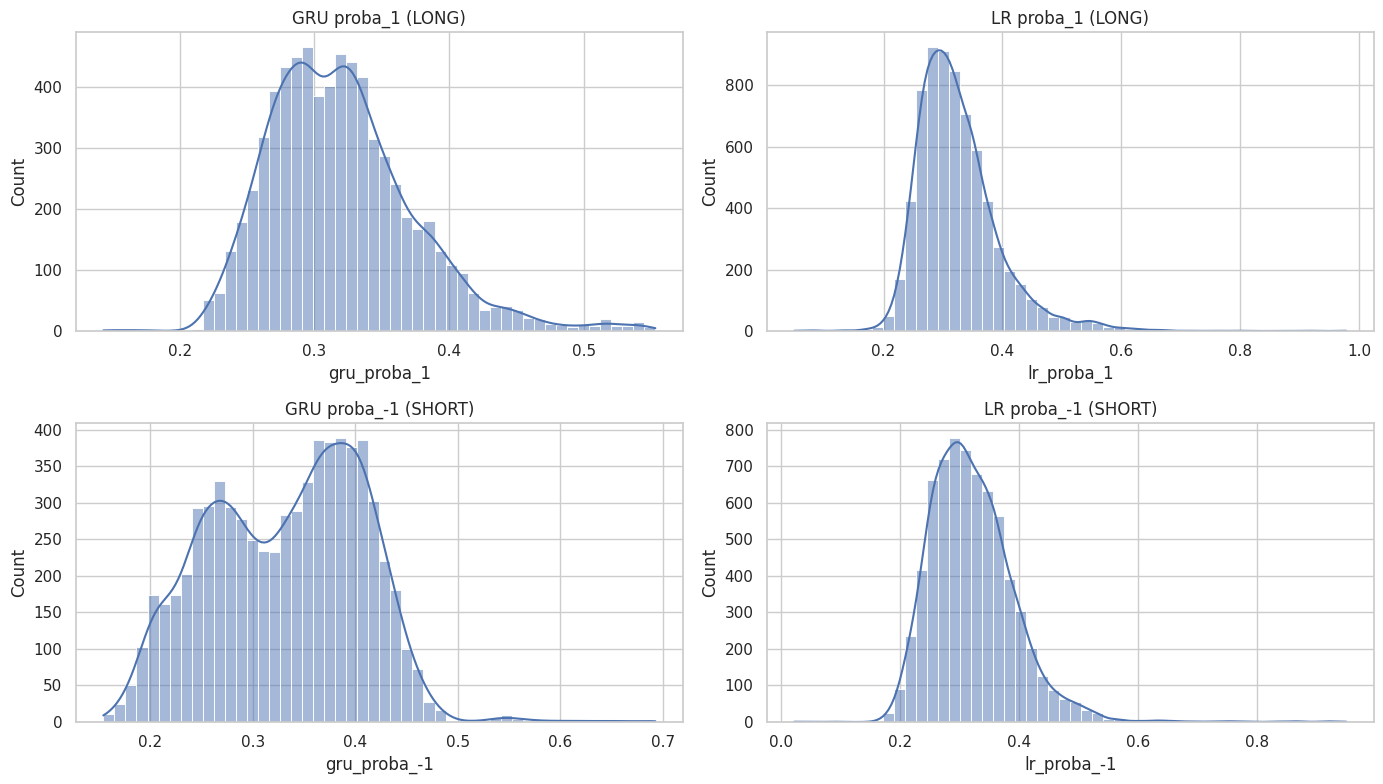

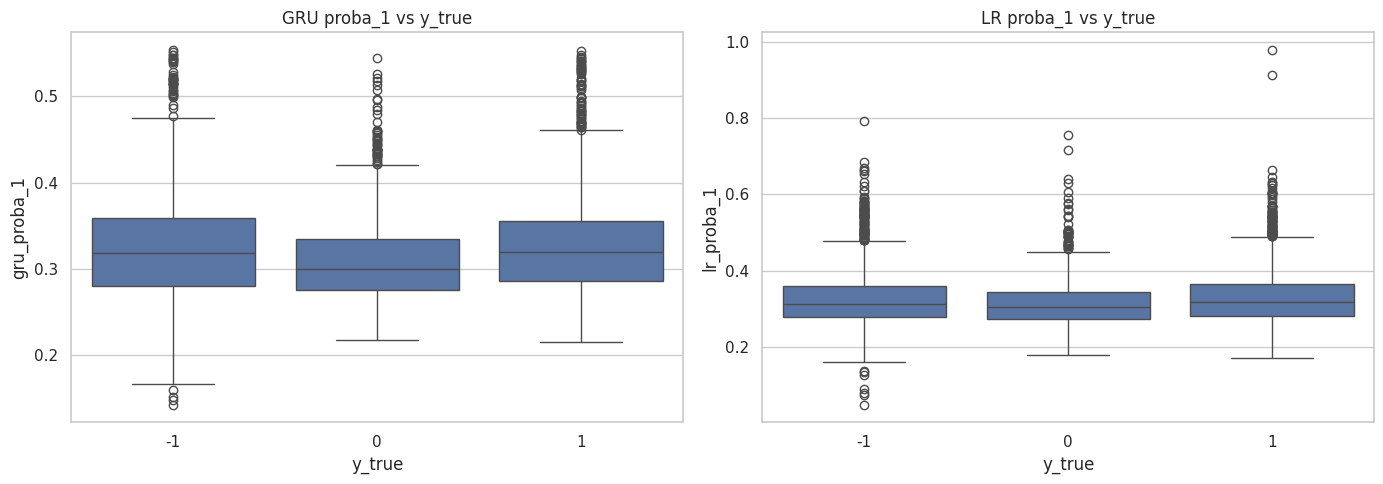

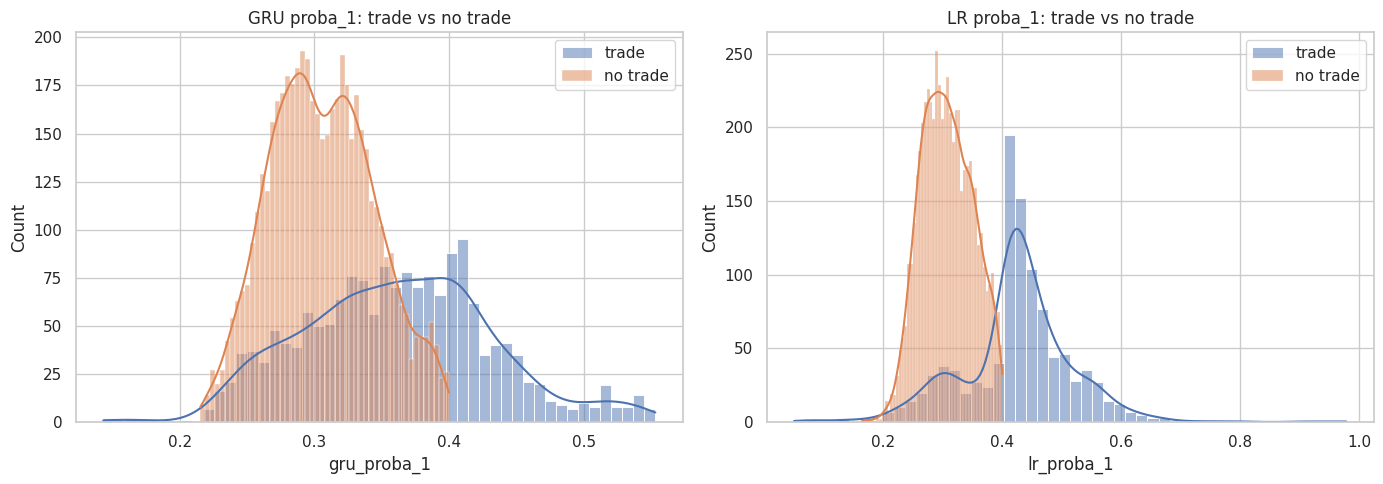

CORRELACIÓN ENTRE MODELOS
Corr LONG  (proba_1):  0.5735
Corr SHORT (proba_-1): 0.7086


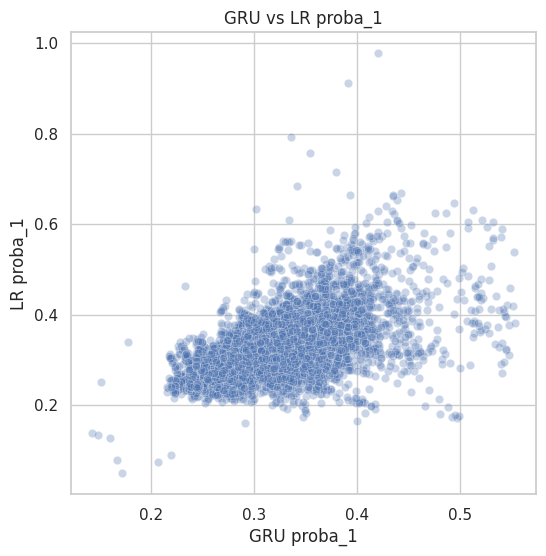

In [ ]:
# =========================================================
# 7. Análisis de probabilidades GRU vs LR
# =========================================================

print("=" * 80)
print("ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES")
print("=" * 80)


# =========================================================
# 7.1. Histogramas de probabilidades long y short
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_valid_cmp["gru_proba_1"], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("GRU proba_1 (LONG)")

sns.histplot(df_valid_cmp["lr_proba_1"], bins=50, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("LR proba_1 (LONG)")

sns.histplot(df_valid_cmp["gru_proba_-1"], bins=50, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("GRU proba_-1 (SHORT)")

sns.histplot(df_valid_cmp["lr_proba_-1"], bins=50, ax=axes[1, 1], kde=True)
axes[1, 1].set_title("LR proba_-1 (SHORT)")

plt.tight_layout()
plt.show()


# =========================================================
# 7.2. Probabilidades vs clase real
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_valid_cmp, x="y_true", y="gru_proba_1", ax=axes[0])
axes[0].set_title("GRU proba_1 vs y_true")

sns.boxplot(data=df_valid_cmp, x="y_true", y="lr_proba_1", ax=axes[1])
axes[1].set_title("LR proba_1 vs y_true")

plt.tight_layout()
plt.show()


# =========================================================
# 7.3. Probabilidades en trades vs no trades
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df_valid_cmp[df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    label="trade",
    ax=axes[0],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    label="no trade",
    ax=axes[0],
    kde=True
)

axes[0].legend()
axes[0].set_title("GRU proba_1: trade vs no trade")

sns.histplot(
    df_valid_cmp[df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    label="trade",
    ax=axes[1],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    label="no trade",
    ax=axes[1],
    kde=True
)

axes[1].legend()
axes[1].set_title("LR proba_1: trade vs no trade")

plt.tight_layout()
plt.show()


# =========================================================
# 7.4. Correlación entre modelos
# =========================================================

corr_long = np.corrcoef(
    df_valid_cmp["gru_proba_1"],
    df_valid_cmp["lr_proba_1"]
)[0, 1]

corr_short = np.corrcoef(
    df_valid_cmp["gru_proba_-1"],
    df_valid_cmp["lr_proba_-1"]
)[0, 1]

print("=" * 80)
print("CORRELACIÓN ENTRE MODELOS")
print("=" * 80)
print(f"Corr LONG  (proba_1):  {corr_long:.4f}")
print(f"Corr SHORT (proba_-1): {corr_short:.4f}")


# =========================================================
# 7.5. Scatter plot GRU vs LR
# =========================================================

plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=df_valid_cmp["gru_proba_1"],
    y=df_valid_cmp["lr_proba_1"],
    alpha=0.3
)

plt.title("GRU vs LR proba_1")
plt.xlabel("GRU proba_1")
plt.ylabel("LR proba_1")
plt.show()

* GRU presenta probabilidades concentradas en un rango estrecho (≈ 0.28–0.38) → baja dispersión y menor nivel de confianza.

* LR muestra mayor dispersión y colas hacia valores altos → mejor capacidad de generar señales de alta confianza.

* La separación por clase (`y_true`) es débil en ambos modelos → fuerte solapamiento entre clases.

* LR presenta algunos valores extremos en clase 1 → potencial utilidad en zonas de alta probabilidad.

* En GRU, la distribución de *trade vs no trade* está bastante solapada → los thresholds actuales no separan claramente señal y ruido.

* En LR, los trades se concentran en probabilidades más altas → mejor comportamiento como filtro.

* Correlación moderada-alta:

  * LONG: 0.57
  * SHORT: 0.71

→ Los modelos comparten información relevante, especialmente en señales short.

* El scatter muestra relación positiva pero con dispersión → no son independientes, pero tampoco redundantes.

* Existe margen para combinación (ensemble), pero no se espera ganancia significativa vía confirmación estricta (AND).


# **8. Construcción y comparación de estrategias sobre VALID**

En este paso se construyen distintas reglas de decisión para transformar las probabilidades de los modelos en señales operativas.

Se comparan estrategias individuales y estrategias combinadas entre GRU y Logistic Regression, manteniendo el análisis sobre el split valid OOS.

El objetivo es evaluar qué esquema convierte mejor las probabilidades en trades útiles, considerando actividad, precisión condicional y proporción total de señales útiles.

In [ ]:
# =========================================================
# 8. Construcción y comparación de estrategias sobre VALID
# =========================================================

# Copia de trabajo para construir señales de estrategia
df_strat = df_valid_cmp.copy()


# =========================================================
# 8.1. Función auxiliar para evaluar una estrategia
# =========================================================

def evaluate_strategy(df, signal_col, name):
    """
    Evalúa una estrategia basada en una señal operativa:
        1  = long
       -1  = short
        0  = no trade
    """

    signal = df[signal_col]
    y_true = df["y_true"]

    trade_mask = signal != 0
    n_obs = len(df)
    n_trades = trade_mask.sum()

    if n_trades == 0:
        n_useful = 0
        precision_useful = np.nan
    else:
        n_useful = (signal[trade_mask] == y_true[trade_mask]).sum()
        precision_useful = n_useful / n_trades

    trade_rate = n_trades / n_obs
    useful_rate_total = n_useful / n_obs

    return {
        "strategy": name,
        "n_obs": n_obs,
        "n_trades": n_trades,
        "trade_rate": trade_rate,
        "n_useful": n_useful,
        "precision_useful": precision_useful,
        "useful_rate_total": useful_rate_total,
    }


# =========================================================
# 8.2. Estrategia 1: GRU baseline
# =========================================================

# Usa directamente la señal generada por el modelo GRU
df_strat["signal_gru_baseline"] = df_strat["gru_signal_raw"]


# =========================================================
# 8.3. Estrategia 2: Logistic Regression baseline
# =========================================================

# Usa directamente la señal generada por Logistic Regression
df_strat["signal_lr_baseline"] = df_strat["lr_signal_raw"]


# =========================================================
# 8.4. Estrategia 3: Ensemble por promedio simple
# =========================================================

# Promedio de probabilidades long y short entre GRU y LR
df_strat["ens_score_long"] = (
    df_strat["gru_proba_1"] + df_strat["lr_proba_1"]
) / 2

df_strat["ens_score_short"] = (
    df_strat["gru_proba_-1"] + df_strat["lr_proba_-1"]
) / 2

# Umbrales iniciales del ensemble
thr_ens_long = 0.40
thr_ens_short = 0.40

# Señal inicial: 0 = no trade
df_strat["signal_ensemble_avg"] = 0

# Señal long
df_strat.loc[
    df_strat["ens_score_long"] >= thr_ens_long,
    "signal_ensemble_avg"
] = 1

# Señal short
df_strat.loc[
    df_strat["ens_score_short"] >= thr_ens_short,
    "signal_ensemble_avg"
] = -1

# Resolución de conflictos:
# si long y short superan threshold, se elige el score mayor
conflict_mask = (
    (df_strat["ens_score_long"] >= thr_ens_long) &
    (df_strat["ens_score_short"] >= thr_ens_short)
)

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] > df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_short"] > df_strat["ens_score_long"]),
    "signal_ensemble_avg"
] = -1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] == df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 0


# =========================================================
# 8.5. Estrategia 4: LR dominante + GRU complemento
# =========================================================

# Idea:
# - LR decide cuando tiene alta confianza.
# - Si LR no genera señal, GRU puede aportar una señal secundaria.
# - Se evita operar con GRU si LR contradice claramente la dirección.

thr_lr_long_main = 0.45
thr_lr_short_main = 0.45

thr_gru_long_secondary = 0.42
thr_gru_short_secondary = 0.42

# Señal inicial: 0 = no trade
df_strat["signal_lr_gru_hybrid"] = 0

# Señal principal por LR
df_strat.loc[
    df_strat["lr_proba_1"] >= thr_lr_long_main,
    "signal_lr_gru_hybrid"
] = 1

df_strat.loc[
    df_strat["lr_proba_-1"] >= thr_lr_short_main,
    "signal_lr_gru_hybrid"
] = -1

# GRU actúa solo si LR no decidió
no_signal_mask = df_strat["signal_lr_gru_hybrid"] == 0

# Señal long secundaria por GRU
df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_1"] >= thr_gru_long_secondary) &
    (df_strat["lr_proba_-1"] < thr_lr_short_main),
    "signal_lr_gru_hybrid"
] = 1

# Señal short secundaria por GRU
df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_-1"] >= thr_gru_short_secondary) &
    (df_strat["lr_proba_1"] < thr_lr_long_main),
    "signal_lr_gru_hybrid"
] = -1


# =========================================================
# 8.6. Evaluación comparativa de estrategias
# =========================================================

strategy_cols = {
    "GRU baseline": "signal_gru_baseline",
    "LR baseline": "signal_lr_baseline",
    "Ensemble avg": "signal_ensemble_avg",
    "LR dominant + GRU": "signal_lr_gru_hybrid",
}

results = []

for strategy_name, signal_col in strategy_cols.items():
    results.append(
        evaluate_strategy(
            df=df_strat,
            signal_col=signal_col,
            name=strategy_name,
        )
    )

df_strategy_results = pd.DataFrame(results)

df_strategy_results = df_strategy_results.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("COMPARACIÓN DE ESTRATEGIAS - VALID OOS")
print("=" * 80)

display(df_strategy_results)

COMPARACIÓN DE ESTRATEGIAS - VALID OOS


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total
0,LR baseline,6882,1037,0.150683,493,0.475410,0.071636
1,Ensemble avg,6882,1303,0.189334,612,0.469685,0.088928
2,GRU baseline,6882,1691,0.245713,783,0.463040,0.113775
3,LR dominant + GRU,6882,1221,0.177419,559,0.457821,0.081226


Gus, está bien encaminado, pero hay un punto importante: **no es opinión, es lectura correcta de los datos**. Lo que escribiste es consistente con los resultados.

Te hago un ajuste fino para que quede más sólido y riguroso.

---

Observaciones

* GRU presenta la mayor tasa de operación (0.2457), lo que implica mayor cobertura de oportunidades.
* Logistic Regression muestra la mayor precisión condicional (0.4754), pero con menor actividad.
* Ensemble logra un equilibrio intermedio entre volumen y precisión, pero no supera al GRU en utilidad total.
* La estrategia híbrida (LR dominante + GRU) no mejora el desempeño respecto a GRU baseline ni al ensemble.

---

Diagnóstico

1. Dominancia del GRU en términos operativos

* GRU maximiza `useful_rate_total`, que es la métrica más relevante desde el punto de vista operativo.
* A pesar de menor precisión, compensa con mayor volumen de señales útiles.

Esto indica que el modelo está capturando más oportunidades, aunque con mayor nivel de ruido.

---

2. Rol de Logistic Regression

* LR actúa como modelo más conservador, con mayor precisión pero menor frecuencia de operación.
* Su contribución principal está en la calidad de señales, no en la cantidad.

---

3. Limitaciones del ensemble

* El promedio de probabilidades mejora ligeramente la precisión respecto a GRU.
* Sin embargo, reduce el número de trades, lo que impacta negativamente en `useful_rate_total`.

No se observa una mejora neta en desempeño operativo.

---

4. Estrategia híbrida

* No logra capturar beneficios claros de ninguno de los dos modelos.
* Pierde tanto en volumen como en precisión relativa.

Puede descartarse como enfoque principal.

---

Conclusión

* El modelo GRU baseline constituye la mejor estrategia inicial bajo las reglas actuales.
* Las combinaciones evaluadas no logran mejorar simultáneamente volumen y calidad de señal.

---

Interpretación

* La señal del GRU es válida, pero está distribuida en rangos de probabilidad medios.
* El problema no es la capacidad predictiva del modelo, sino la forma en que se están utilizando sus probabilidades para generar decisiones.

---

**Siguiente paso**

* No es conveniente continuar explorando combinaciones entre modelos en esta etapa.
* El foco debe desplazarse hacia la calibración de thresholds del GRU.

Se propone:

* realizar un barrido sistemático de thresholds
* analizar el trade-off entre:

  * volumen de operaciones
  * precisión condicional
  * utilidad total

---

**Conclusión final (ajuste clave)**

> El problema no es el modelo, es la función de decisión.

Si mantenés eso claro, el resto del pipeline queda alineado.


# **9. Barrido de theresholds para GRU baseline**

En este paso se realiza un barrido sistemático de thresholds sobre las probabilidades del modelo GRU, con el objetivo de analizar cómo cambian las señales generadas en función de distintos niveles de decisión.

Se evalúa cada combinación de umbrales para posiciones long y short, midiendo su impacto en la frecuencia de operación, la precisión condicional y la proporción total de señales útiles.

Este análisis permite entender el trade-off entre volumen y calidad de señal, y constituye la base para definir una regla de decisión operativa más adecuada.

BARRIDO DE THRESHOLDS - GRU BASELINE


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,5321,0.773176,2226,0.418342,0.323452,0.30,0.30
1,GRU threshold grid,6882,5258,0.764022,2208,0.419932,0.320837,0.30,0.31
2,GRU threshold grid,6882,5057,0.734815,2195,0.434052,0.318948,0.30,0.34
3,GRU threshold grid,6882,5134,0.746004,2195,0.427542,0.318948,0.30,0.33
4,GRU threshold grid,6882,5198,0.755304,2190,0.421316,0.318221,0.30,0.32
5,GRU threshold grid,6882,4971,0.722319,2164,0.435325,0.314443,0.30,0.35
6,GRU threshold grid,6882,4884,0.709677,2127,0.435504,0.309067,0.30,0.36
7,GRU threshold grid,6882,5086,0.739029,2124,0.417617,0.308631,0.31,0.30
8,GRU threshold grid,6882,4999,0.726388,2098,0.419684,0.304853,0.31,0.31
9,GRU threshold grid,6882,4844,0.703865,2075,0.428365,0.301511,0.31,0.33


TOP CONFIGURACIONES CON trade_rate >= 0.05


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56
1,GRU threshold grid,6882,432,0.062772,230,0.532407,0.033421,0.41,0.54
2,GRU threshold grid,6882,423,0.061465,225,0.531915,0.032694,0.41,0.55
3,GRU threshold grid,6882,435,0.063208,229,0.526437,0.033275,0.41,0.53
4,GRU threshold grid,6882,436,0.063354,229,0.525229,0.033275,0.41,0.52
5,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.50
6,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.51
7,GRU threshold grid,6882,438,0.063644,228,0.520548,0.033130,0.41,0.49
8,GRU threshold grid,6882,346,0.050276,179,0.517341,0.026010,0.42,0.49
9,GRU threshold grid,6882,449,0.065243,231,0.514477,0.033566,0.41,0.48


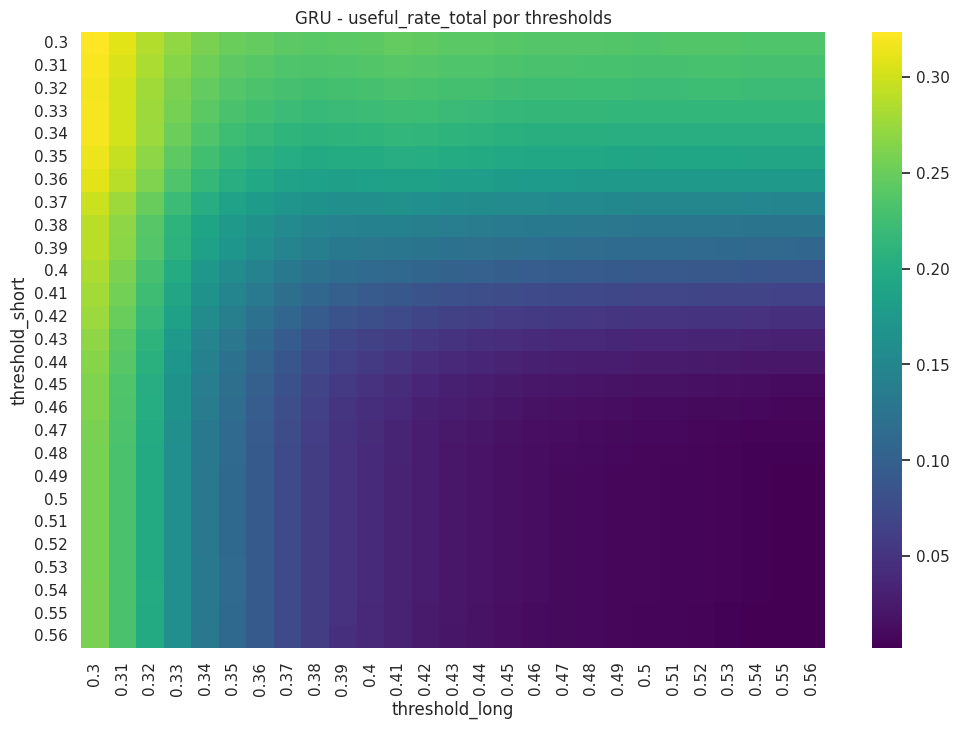

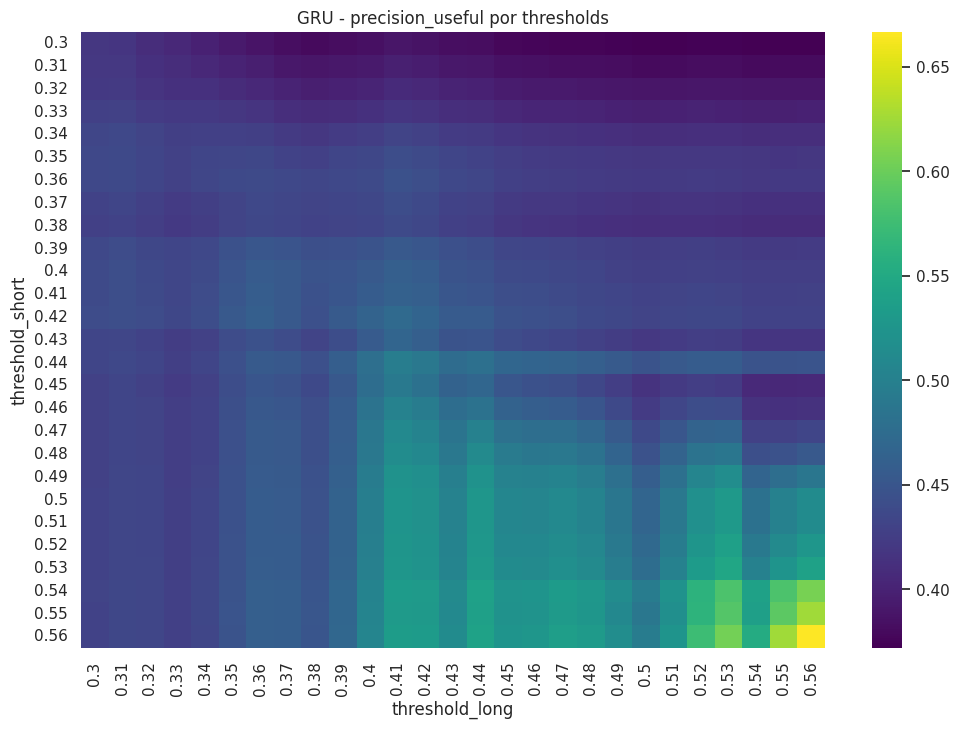

In [ ]:
# =========================================================
# 9. Barrido de thresholds para GRU baseline
# =========================================================

df_gru_thr = df_strat.copy()


# =========================================================
# 9.1. Función para generar señales con thresholds variables
# =========================================================

def build_signal_from_thresholds(
    df: pd.DataFrame,
    proba_long_col: str,
    proba_short_col: str,
    threshold_long: float,
    threshold_short: float,
) -> np.ndarray:
    """
    Genera señales operativas:
        1  = long
       -1  = short
        0  = no trade

    Si long y short superan threshold al mismo tiempo,
    se elige la dirección con mayor probabilidad.
    """

    p_long = df[proba_long_col].values
    p_short = df[proba_short_col].values

    long_mask = p_long >= threshold_long
    short_mask = p_short >= threshold_short

    signal = np.zeros(len(df), dtype=int)

    # Casos sin conflicto
    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    # Casos con conflicto
    conflict_mask = long_mask & short_mask

    signal[conflict_mask & (p_long > p_short)] = 1
    signal[conflict_mask & (p_short > p_long)] = -1
    signal[conflict_mask & (p_long == p_short)] = 0

    return signal


# =========================================================
# 9.2. Definición del grid de thresholds
# =========================================================

# Rango de thresholds a evaluar para long y short
threshold_values = np.round(np.arange(0.30, 0.56, 0.01), 2)

results_thr = []

for thr_long in threshold_values:
    for thr_short in threshold_values:

        # Generar señal GRU usando la combinación actual de thresholds
        signal = build_signal_from_thresholds(
            df=df_gru_thr,
            proba_long_col="gru_proba_1",
            proba_short_col="gru_proba_-1",
            threshold_long=thr_long,
            threshold_short=thr_short,
        )

        # Copia temporal para evaluar la estrategia
        tmp = df_gru_thr.copy()
        tmp["signal_gru_thr"] = signal

        # Evaluar métricas operativas
        metrics = evaluate_strategy(
            df=tmp,
            signal_col="signal_gru_thr",
            name="GRU threshold grid",
        )

        # Registrar thresholds evaluados
        metrics["threshold_long"] = thr_long
        metrics["threshold_short"] = thr_short

        results_thr.append(metrics)


# Consolidar resultados del barrido
df_gru_threshold_grid = pd.DataFrame(results_thr)


# =========================================================
# 9.3. Ranking por useful_rate_total
# =========================================================

df_gru_threshold_grid = df_gru_threshold_grid.sort_values(
    by=["useful_rate_total", "precision_useful", "trade_rate"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("BARRIDO DE THRESHOLDS - GRU BASELINE")
print("=" * 80)

display(df_gru_threshold_grid.head(20))


# =========================================================
# 9.4. Ranking con filtro operativo mínimo
# =========================================================

# Filtro mínimo para evitar configuraciones con muy baja actividad
min_trade_rate = 0.05

df_gru_threshold_filtered = df_gru_threshold_grid[
    df_gru_threshold_grid["trade_rate"] >= min_trade_rate
].copy()

df_gru_threshold_filtered = df_gru_threshold_filtered.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print(f"TOP CONFIGURACIONES CON trade_rate >= {min_trade_rate}")
print("=" * 80)

display(df_gru_threshold_filtered.head(20))


# =========================================================
# 9.5. Heatmap de useful_rate_total
# =========================================================

heatmap_useful = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="useful_rate_total",
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_useful,
    cmap="viridis",
    annot=False
)

plt.title("GRU - useful_rate_total por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()


# =========================================================
# 9.6. Heatmap de precision_useful
# =========================================================

heatmap_precision = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="precision_useful",
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_precision,
    cmap="viridis",
    annot=False
)

plt.title("GRU - precision_useful por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()

## **Observaciones generales**



Cuando los thresholds son bajos (≈ 0.30):

* el modelo opera muy frecuentemente (más del 70% de las observaciones)
* el `useful_rate_total` alcanza sus valores máximos
* la precisión es relativamente baja (~0.42–0.43)

Esto implica alto volumen de operaciones, pero con mayor presencia de ruido.

---

A medida que aumentan los thresholds:

* disminuye significativamente el número de trades
* aumenta la precisión de las señales

Se observa un comportamiento más selectivo, con menor cantidad de operaciones pero de mayor calidad.

---

En thresholds altos (≈ 0.50 o superiores):

* la precisión supera el 0.50
* la tasa de operación cae a niveles bajos (~5–8%)
* el `useful_rate_total` disminuye considerablemente

Esto corresponde a un comportamiento excesivamente conservador, donde se pierden muchas oportunidades.

---

Lectura del heatmap

* La zona con mayor `useful_rate_total` se encuentra en thresholds bajos (0.30–0.35).
* La zona con mayor precisión se encuentra en thresholds altos (0.50–0.56).

Existe un trade-off claro entre volumen de operaciones y calidad de señal.

---

Insight principal

El modelo GRU presenta señal predictiva, pero esta se concentra en rangos de probabilidad intermedios (0.30–0.40), y no en valores extremos.

Como consecuencia:

* thresholds altos eliminan gran parte de las oportunidades
* thresholds bajos incorporan ruido en la toma de decisiones

---

Zona operativamente relevante

Los resultados sugieren que thresholds alrededor de:

* `threshold_long ≈ 0.40–0.42`
* `threshold_short ≈ 0.45–0.55`

permiten obtener:

* precisión cercana a 0.50
* `trade_rate` entre 0.06 y 0.08

Esto implica señales de mayor calidad, aunque con menor frecuencia.

---

Conclusión

* thresholds demasiado bajos generan exceso de ruido
* thresholds demasiado altos reducen excesivamente la actividad
* el baseline (0.40 / 0.40) se ubica en una zona razonable de compromiso entre volumen y calidad

---

Idea clave

El desempeño del modelo no es el problema principal.

El factor crítico es la definición de la regla de decisión, es decir, la selección de thresholds sobre las probabilidades.

---

Siguiente paso

Se recomienda definir un conjunto reducido de configuraciones candidatas de thresholds y compararlas directamente, en lugar de continuar con un barrido exhaustivo.

Este paso marca la transición desde el análisis hacia la definición de una estrategia operativa.


# **10. Selección y comparación de configuraciones candidatas**

En este paso se selecciona un conjunto reducido de configuraciones de thresholds a partir del análisis previo, con el objetivo de evaluarlas de forma directa y controlada.

Se busca comparar alternativas representativas del trade-off entre volumen y calidad de señal, permitiendo identificar configuraciones operativas viables sin depender de un barrido exhaustivo.

In [ ]:
# =========================================================
# 10. Selección y comparación de configuraciones candidatas
# =========================================================

# =========================================================
# 10.1. Definición de configuraciones candidatas
# =========================================================

candidate_configs = [
    {
        "strategy": "GRU baseline",
        "threshold_long": 0.40,
        "threshold_short": 0.40,
        "description": "Configuración base utilizada hasta el momento",
    },
    {
        "strategy": "GRU balanced",
        "threshold_long": 0.40,
        "threshold_short": 0.45,
        "description": "Configuración levemente más conservadora en short",
    },
    {
        "strategy": "GRU conservative",
        "threshold_long": 0.41,
        "threshold_short": 0.50,
        "description": "Configuración orientada a mayor precisión",
    },
    {
        "strategy": "GRU high_precision",
        "threshold_long": 0.41,
        "threshold_short": 0.56,
        "description": "Configuración de máxima precisión observada en el grid",
    },
]


# =========================================================
# 10.2. Evaluación de configuraciones candidatas
# =========================================================

candidate_results = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_strat,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_strat.copy()
    tmp["signal_candidate"] = signal

    metrics = evaluate_strategy(
        df=tmp,
        signal_col="signal_candidate",
        name=config["strategy"],
    )

    metrics["threshold_long"] = config["threshold_long"]
    metrics["threshold_short"] = config["threshold_short"]
    metrics["description"] = config["description"]

    candidate_results.append(metrics)


df_candidate_results = pd.DataFrame(candidate_results)


# =========================================================
# 10.3. Ordenamiento de resultados
# =========================================================

df_candidate_results = df_candidate_results.sort_values(
    by=["useful_rate_total", "precision_useful"],
    ascending=False
).reset_index(drop=True)


# =========================================================
# 10.4. Visualización de resultados
# =========================================================

print("=" * 80)
print("COMPARACIÓN DE CONFIGURACIONES CANDIDATAS - GRU")
print("=" * 80)

display(df_candidate_results)

COMPARACIÓN DE CONFIGURACIONES CANDIDATAS - GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short,description
0,GRU baseline,6882,1691,0.245713,766,0.452986,0.111305,0.40,0.40,Configuración base utilizada hasta el momento
1,GRU balanced,6882,699,0.101569,333,0.476395,0.048387,0.40,0.45,Configuración levemente más conservadora en short
2,GRU conservative,6882,437,0.063499,229,0.524027,0.033275,0.41,0.50,Configuración orientada a mayor precisión
3,GRU high_precision,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56,Configuración de máxima precisión observada en...


* **GRU baseline** mantiene el mayor `useful_rate_total` con diferencia: 0.1113.
* **GRU balanced** mejora la precisión respecto al baseline, pero reduce mucho el volumen de trades.
* **GRU conservative** y **high_precision** logran precisión superior a 0.52, pero operan muy poco.
* El aumento de precisión no compensa la caída de actividad.
* Para una estrategia con flujo operativo, el **baseline sigue siendo la mejor configuración inicial**.
* Para una estrategia más selectiva, **GRU balanced** es la alternativa razonable.
* Las configuraciones `conservative` y `high_precision` quedan como referencias de alta precisión, pero no como estrategia principal.


# **11. Validación en TEST OOS**

En este paso se evalúan en test las configuraciones candidatas definidas previamente sobre valid.

El objetivo es verificar si las reglas de decisión mantienen un comportamiento estable fuera del conjunto utilizado para el diseño de la estrategia.

Para evitar sobreajuste, no se modifican thresholds ni reglas en esta etapa; simplemente se aplican las mismas configuraciones y se comparan sus métricas operativas.

In [ ]:
# =========================================================
# 11. Validación en TEST OOS
# =========================================================

# =========================================================
# 11.1. Selección de datos TEST para GRU
# =========================================================

split_test = "test"

df_gru_test = df_prob_oos[
    (df_prob_oos["split"] == split_test) &
    (df_prob_oos["target"] == target_strategy) &
    (df_prob_oos["model"] == "gru")
].reset_index(drop=True).copy()

print("=" * 80)
print("DATASET TEST OOS - GRU")
print("=" * 80)
print(f"Shape: {df_gru_test.shape}")
print("=" * 80)


# =========================================================
# 11.2. Adaptación de columnas al formato usado en valid
# =========================================================

df_test_gru_cmp = pd.DataFrame({
    "y_true": df_gru_test["y_true"].values,
    "gru_proba_-1": df_gru_test["proba_-1"].values,
    "gru_proba_0":  df_gru_test["proba_0"].values,
    "gru_proba_1":  df_gru_test["proba_1"].values,
    "gru_pred_label": df_gru_test["pred_label"].values,
    "gru_signal_raw": df_gru_test["signal_raw"].values,
    "gru_trade": df_gru_test["trade"].values,
})


# =========================================================
# 11.3. Evaluación de configuraciones candidatas en TEST
# =========================================================

test_results = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_test_gru_cmp,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_test_gru_cmp.copy()
    tmp["signal_candidate"] = signal

    metrics = evaluate_strategy(
        df=tmp,
        signal_col="signal_candidate",
        name=config["strategy"],
    )

    metrics["split"] = "test"
    metrics["threshold_long"] = config["threshold_long"]
    metrics["threshold_short"] = config["threshold_short"]
    metrics["description"] = config["description"]

    test_results.append(metrics)

df_candidate_results_test = pd.DataFrame(test_results)


# =========================================================
# 11.4. Ordenamiento de resultados TEST
# =========================================================

df_candidate_results_test = df_candidate_results_test.sort_values(
    by=["useful_rate_total", "precision_useful"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("VALIDACIÓN TEST OOS - CONFIGURACIONES GRU")
print("=" * 80)

display(df_candidate_results_test)

DATASET TEST OOS - GRU
Shape: (6913, 18)
VALIDACIÓN TEST OOS - CONFIGURACIONES GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,split,threshold_long,threshold_short,description
0,GRU baseline,6913,916,0.132504,361,0.394105,0.052220,test,0.40,0.40,Configuración base utilizada hasta el momento
1,GRU balanced,6913,309,0.044698,137,0.443366,0.019818,test,0.40,0.45,Configuración levemente más conservadora en short
2,GRU conservative,6913,188,0.027195,72,0.382979,0.010415,test,0.41,0.50,Configuración orientada a mayor precisión
3,GRU high_precision,6913,188,0.027195,72,0.382979,0.010415,test,0.41,0.56,Configuración de máxima precisión observada en...


Observaciones:

* En `test`, todas las configuraciones degradan respecto a `valid`.
* **GRU baseline** sigue siendo la configuración con mayor `useful_rate_total`.
* **GRU balanced** mejora la precisión frente al baseline, pero opera muy poco.
* **GRU conservative** y **high_precision** pierden valor en test: baja actividad y baja precisión.
* Los thresholds más exigentes no generalizan bien.
* La mejor configuración operativa sigue siendo **GRU baseline (0.40 / 0.40)**, aunque con menor calidad OOS.
* El salto `valid → test` indica que antes del backtest conviene analizar estabilidad temporal y costos.


# **12. Evaluación operativa de las señales (PnL)**

En este paso se transforma la señal de trading en resultados económicos, con el objetivo de evaluar el desempeño real de la estrategia más allá de métricas de clasificación.

Se utilizan los retornos futuros asociados al horizonte del target para calcular el resultado de cada operación en función de la señal generada (long, short o no trade).

El análisis permite medir el comportamiento de la estrategia en términos de PnL, incorporando tanto la dirección de la predicción como la magnitud del movimiento del mercado.

De esta forma, se pasa de una evaluación basada en aciertos a una evaluación basada en resultados operativos, que es el criterio relevante para una estrategia de trading.


In [ ]:
# =========================================================
# 12.1. Carga del dataset T2 completo para PnL
# =========================================================

print("=" * 80)
print("CARGA DATASET T2 COMPLETO PARA PnL")
print("=" * 80)

# ---------------------------------------------------------
# Ruta del dataset con precios, régimen, targets y delta_30
# ---------------------------------------------------------

IN_PARQUET_T2_FULL = DRIVE_DIR / Path(os.environ.get(
    "IN_PARQUET_T2_FULL",
    "data/04_features/mnq_t2.parquet"
))

# ---------------------------------------------------------
# Validación de existencia
# ---------------------------------------------------------

assert IN_PARQUET_T2_FULL.exists(), f"No existe: {IN_PARQUET_T2_FULL}"

# ---------------------------------------------------------
# Carga
# ---------------------------------------------------------

df_t2_full = pd.read_parquet(IN_PARQUET_T2_FULL)

print(f"Shape: {df_t2_full.shape}")

# ---------------------------------------------------------
# Validación de columnas necesarias
# ---------------------------------------------------------

required_cols = [
    "date",
    "close",
    "regime_id",
    "delta_30",
    "t2_p40_h30",
]

missing_cols = [col for col in required_cols if col not in df_t2_full.columns]

assert not missing_cols, f"Faltan columnas necesarias: {missing_cols}"

print("\nColumnas necesarias presentes:")
print(required_cols)

# ---------------------------------------------------------
# Inspección rápida de columnas relevantes
# ---------------------------------------------------------

keywords = ["date", "regime", "delta", "close", "t2"]

print("\nColumnas relevantes:")
for kw in keywords:
    cols = [c for c in df_t2_full.columns if kw.lower() in c.lower()]
    print(f"{kw}: {cols}")

print("=" * 80)

CARGA DATASET T2 COMPLETO PARA PnL
Shape: (88920, 22)

Columnas necesarias presentes:
['date', 'close', 'regime_id', 'delta_30', 't2_p40_h30']

Columnas relevantes:
date: ['date']
regime: ['regime_id']
delta: ['delta_30', 'delta_60']
close: ['close', 'close_fwd_30', 'close_fwd_60']
t2: ['t2_p40_h30', 't2_p40_h60', 't2_p50_h30']


In [ ]:
# =========================================================
# 12.2. Alineación exacta por día para ventanas seq2one
# =========================================================

print("=" * 80)
print("VERIFICACIÓN DE ALINEACIÓN POR DÍA")
print("=" * 80)

L = 30
target_col = "t2_p40_h30"

# ---------------------------------------------------------
# 1. Ordenar igual que en el split original
# ---------------------------------------------------------

df_base = (
    df_t2_full
    .sort_values(["date", "minute_of_day"])
    .reset_index(drop=True)
    .copy()
)

df_base["_day"] = pd.to_datetime(df_base["date"]).dt.date

# ---------------------------------------------------------
# 2. Reconstruir split por días
# ---------------------------------------------------------

unique_days = pd.Index(sorted(df_base["_day"].unique()))

n_days = len(unique_days)
n_train_days = int(n_days * 0.70)
n_valid_days = int(n_days * 0.15)

train_days = set(unique_days[:n_train_days])
valid_days = set(unique_days[n_train_days:n_train_days + n_valid_days])
test_days  = set(unique_days[n_train_days + n_valid_days:])

df_valid_raw = df_base[df_base["_day"].isin(valid_days)].copy()
df_test_raw  = df_base[df_base["_day"].isin(test_days)].copy()

print(f"VALID raw rows: {len(df_valid_raw)}")
print(f"TEST raw rows : {len(df_test_raw)}")

# ---------------------------------------------------------
# 3. Aplicar lógica de ventanas por día
# ---------------------------------------------------------
# Para cada día, las primeras L-1 filas no generan ventana seq2one.
# Se conservan las filas desde la posición L-1 en adelante.

df_valid_aligned = (
    df_valid_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

df_test_aligned = (
    df_test_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

print("-" * 80)
print(f"VALID aligned rows: {len(df_valid_aligned)}")
print(f"df_valid_cmp rows : {len(df_valid_cmp)}")
print(f"TEST aligned rows : {len(df_test_aligned)}")
print(f"df_test_gru_cmp   : {len(df_test_gru_cmp)}")

assert len(df_valid_aligned) == len(df_valid_cmp), "VALID no alinea en cantidad."
assert len(df_test_aligned) == len(df_test_gru_cmp), "TEST no alinea en cantidad."

# ---------------------------------------------------------
# 4. Validar alineación real contra y_true
# ---------------------------------------------------------

valid_match = (
    df_valid_aligned[target_col].values == df_valid_cmp["y_true"].values
).mean()

test_match = (
    df_test_aligned[target_col].values == df_test_gru_cmp["y_true"].values
).mean()

print("-" * 80)
print(f"Match VALID y_true: {valid_match:.4f}")
print(f"Match TEST  y_true: {test_match:.4f}")

assert valid_match == 1.0, "VALID no alinea perfectamente."
assert test_match == 1.0, "TEST no alinea perfectamente."

print("-" * 80)
print("OK: alineación perfecta por día.")

# ---------------------------------------------------------
# 5. Agregar variables económicas
# ---------------------------------------------------------

df_valid_cmp["date"] = df_valid_aligned["date"].values
df_valid_cmp["minute_of_day"] = df_valid_aligned["minute_of_day"].values
df_valid_cmp["close"] = df_valid_aligned["close"].values
df_valid_cmp["delta_30"] = df_valid_aligned["delta_30"].values

df_test_gru_cmp["date"] = df_test_aligned["date"].values
df_test_gru_cmp["minute_of_day"] = df_test_aligned["minute_of_day"].values
df_test_gru_cmp["close"] = df_test_aligned["close"].values
df_test_gru_cmp["delta_30"] = df_test_aligned["delta_30"].values

print("Variables económicas agregadas correctamente.")
print("=" * 80)

VERIFICACIÓN DE ALINEACIÓN POR DÍA
VALID raw rows: 13320
TEST raw rows : 13380
--------------------------------------------------------------------------------
VALID aligned rows: 6882
df_valid_cmp rows : 6882
TEST aligned rows : 6913
df_test_gru_cmp   : 6913
--------------------------------------------------------------------------------
Match VALID y_true: 1.0000
Match TEST  y_true: 1.0000
--------------------------------------------------------------------------------
OK: alineación perfecta por día.
Variables económicas agregadas correctamente.


# **13. Cálculo de PnL por estrategia**

En este paso se transforma cada señal en un resultado económico utilizando delta_30.

Se evalúa el desempeño de las configuraciones del modelo GRU en términos de retorno por operación, retorno acumulado y métricas agregadas.

In [ ]:
# =========================================================
# 13. Cálculo de PnL - GRU configuraciones
# =========================================================

print("=" * 80)
print("CÁLCULO DE PnL - GRU")
print("=" * 80)

# ---------------------------------------------------------
# 1. Función PnL
# ---------------------------------------------------------

def compute_pnl(df: pd.DataFrame, signal_col: str) -> pd.DataFrame:
    """
    PnL por operación:
        pnl = signal * delta_30
    """
    df = df.copy()
    df["pnl"] = df[signal_col] * df["delta_30"]
    df["cum_pnl"] = df["pnl"].cumsum()
    return df

# ---------------------------------------------------------
# 2. Construcción de señales (configuraciones GRU)
# ---------------------------------------------------------

def build_signal(df, thr_long, thr_short):
    p_long = df["gru_proba_1"].values
    p_short = df["gru_proba_-1"].values

    signal = np.zeros(len(df), dtype=int)

    long_mask = p_long >= thr_long
    short_mask = p_short >= thr_short

    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    conflict = long_mask & short_mask
    signal[conflict & (p_long > p_short)] = 1
    signal[conflict & (p_short > p_long)] = -1

    return signal

# ---------------------------------------------------------
# 3. Configuraciones a evaluar
# ---------------------------------------------------------

configs = [
    ("baseline", 0.40, 0.40),
    ("balanced", 0.40, 0.45),
    ("conservative", 0.41, 0.50),
    ("high_precision", 0.41, 0.56),
]

results = []

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal"] = build_signal(df_tmp, thr_l, thr_s)

    df_tmp = compute_pnl(df_tmp, "signal")

    trades = df_tmp[df_tmp["signal"] != 0]

    result = {
        "strategy": name,
        "n_trades": len(trades),
        "mean_pnl": trades["pnl"].mean(),
        "total_pnl": trades["pnl"].sum(),
        "win_rate": (trades["pnl"] > 0).mean(),
    }

    results.append(result)

df_pnl = pd.DataFrame(results).sort_values("total_pnl", ascending=False)

print("=" * 80)
print("RESULTADOS PnL")
print("=" * 80)

display(df_pnl)

CÁLCULO DE PnL - GRU
RESULTADOS PnL


,strategy,n_trades,mean_pnl,total_pnl,win_rate
1,balanced,309,12.675566,3916.75,0.514563
0,baseline,916,2.474072,2266.25,0.465066
2,conservative,188,1.686170,317.00,0.462766
3,high_precision,188,1.686170,317.00,0.462766


## **Observaciones**



La configuración **balanced (0.40 / 0.45)** presenta el mejor desempeño en términos de resultado total. Genera el mayor beneficio acumulado con un número moderado de operaciones, y además muestra una mejora tanto en la ganancia promedio por operación como en la proporción de aciertos.

La configuración **baseline (0.40 / 0.40)** mantiene relevancia. Aunque la ganancia por operación es menor, compensa mediante un mayor número de trades, lo que permite alcanzar un resultado total positivo, aunque inferior al de la configuración balanced.

Las configuraciones **conservative** y **high precision** no resultan efectivas. Al ser demasiado restrictivas, reducen significativamente la cantidad de operaciones sin lograr una mejora suficiente en la calidad de las señales. Como consecuencia, el resultado total es considerablemente menor.

**Interpretación**

El análisis muestra que existe un equilibrio necesario entre la cantidad de operaciones y la calidad de las mismas. Ajustar los thresholds permite mejorar la calidad de las señales, pero si el criterio se vuelve demasiado estricto, el sistema deja de operar con suficiente frecuencia y pierde capacidad de generar beneficios.

En este contexto, la configuración balanced logra un balance adecuado entre volumen y calidad, posicionándose como el mejor compromiso entre ambos factores.

**Conclusión**

La configuración **GRU balanced (0.40 / 0.45)** se destaca como la mejor alternativa observada hasta el momento. Esto se debe a que:

* maximiza el beneficio total
* mejora la calidad de cada operación
* mantiene un nivel de actividad suficiente para sostener el rendimiento

**Siguiente paso**

A partir de estos resultados, es necesario analizar la estabilidad del sistema. Para ello, se debe evaluar:

* la evolución del beneficio acumulado en el tiempo
* la presencia de caídas significativas (drawdowns)
* el impacto de costos operativos como comisiones y deslizamientos

Este análisis permitirá determinar si el rendimiento observado es consistente y si el sistema puede considerarse viable en un entorno real.


# **14. Equity curve, drawdown y costos - GRU balanced**

En este paso se realiza la evaluación económica completa de la estrategia seleccionada, trasladando las señales generadas por el modelo a resultados monetarios reales.

A partir de las probabilidades del modelo GRU y los thresholds definidos previamente, se construyen las señales de trading sobre el conjunto de test.

Estas señales se combinan con la variación futura del precio (`delta_30`) para calcular el resultado de cada operación.

El análisis considera tanto el rendimiento bruto como el rendimiento neto, incorporando costos operativos como comisiones y deslizamientos. De esta forma, se obtiene una estimación más realista del comportamiento del sistema en un entorno de trading.

Adicionalmente, se evalúan métricas clave como:

* beneficio total y promedio por operación
* tasa de aciertos
* drawdown máximo
* factor de beneficio

Finalmente, se visualiza la evolución del capital a lo largo del tiempo, el drawdown y la distribución de resultados por trade, con el objetivo de analizar la estabilidad, el riesgo y la calidad del sistema.


EVALUACIÓN ECONÓMICA - GRU BALANCED
Costo estimado por trade: 3.50 USD
MÉTRICAS ECONÓMICAS


,strategy,threshold_long,threshold_short,n_trades,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net,max_drawdown_usd,profit_factor_gross,profit_factor_net
0,GRU balanced,0.4,0.45,309,7833.5,6752.0,25.351133,21.851133,0.514563,0.511327,-7422.0,1.398357,1.334398


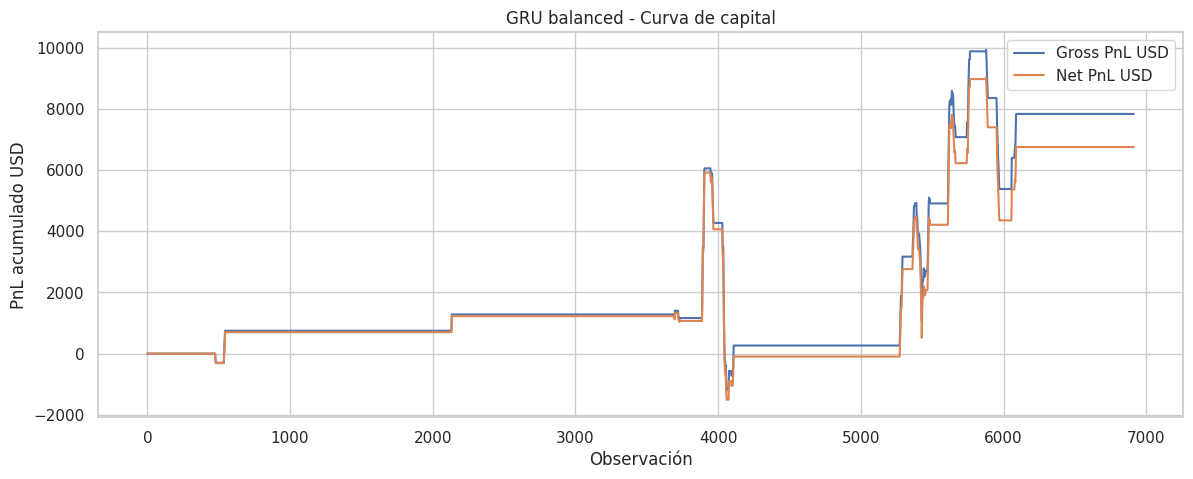

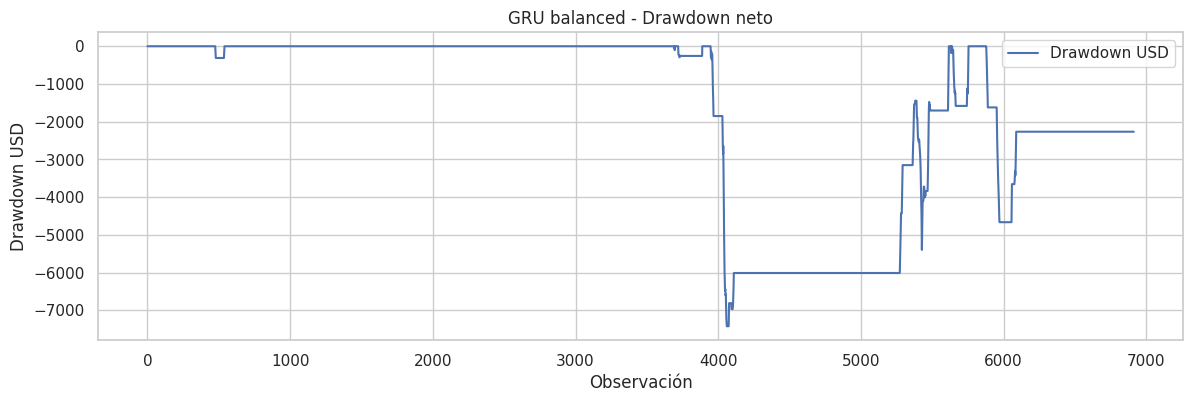

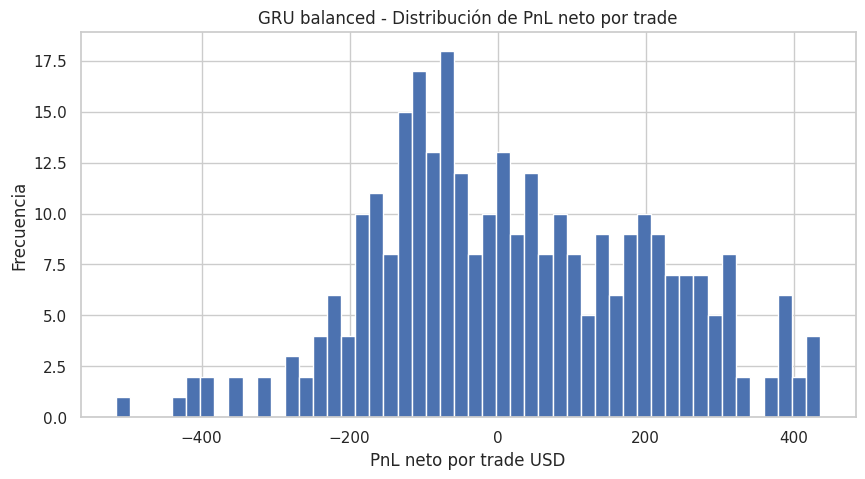

In [ ]:
# =========================================================
# 14. Equity curve, drawdown y costos - GRU balanced
# =========================================================

print("=" * 80)
print("EVALUACIÓN ECONÓMICA - GRU BALANCED")
print("=" * 80)

# ---------------------------------------------------------
# 14.1. Parámetros económicos MNQ
# ---------------------------------------------------------

POINT_VALUE_USD = 2.0      # MNQ: 1 punto = 2 USD por contrato
N_CONTRACTS = 1

COMMISSION_PER_SIDE_USD = 1.25
SLIPPAGE_POINTS_PER_SIDE = 0.25

COST_PER_TRADE_USD = (
    2 * COMMISSION_PER_SIDE_USD +
    2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
) * N_CONTRACTS

print(f"Costo estimado por trade: {COST_PER_TRADE_USD:.2f} USD")


# ---------------------------------------------------------
# 14.2. Construcción de señal GRU balanced en TEST
# ---------------------------------------------------------

thr_long = 0.40
thr_short = 0.45

df_equity = df_test_gru_cmp.copy()

df_equity["signal"] = build_signal(
    df_equity,
    thr_long=thr_long,
    thr_short=thr_short,
)

df_equity["trade"] = df_equity["signal"] != 0


# ---------------------------------------------------------
# 14.3. PnL bruto y neto
# ---------------------------------------------------------

df_equity["pnl_points"] = df_equity["signal"] * df_equity["delta_30"]

df_equity["pnl_usd_gross"] = (
    df_equity["pnl_points"] * POINT_VALUE_USD * N_CONTRACTS
)

df_equity["cost_usd"] = np.where(
    df_equity["trade"],
    COST_PER_TRADE_USD,
    0.0
)

df_equity["pnl_usd_net"] = df_equity["pnl_usd_gross"] - df_equity["cost_usd"]

df_equity["cum_pnl_usd_gross"] = df_equity["pnl_usd_gross"].cumsum()
df_equity["cum_pnl_usd_net"] = df_equity["pnl_usd_net"].cumsum()


# ---------------------------------------------------------
# 14.4. Drawdown
# ---------------------------------------------------------

df_equity["equity_peak"] = df_equity["cum_pnl_usd_net"].cummax()
df_equity["drawdown_usd"] = df_equity["cum_pnl_usd_net"] - df_equity["equity_peak"]

max_drawdown_usd = df_equity["drawdown_usd"].min()


# ---------------------------------------------------------
# 14.5. Métricas económicas
# ---------------------------------------------------------

trades = df_equity[df_equity["trade"]].copy()

metrics_economic = {
    "strategy": "GRU balanced",
    "threshold_long": thr_long,
    "threshold_short": thr_short,
    "n_trades": len(trades),
    "gross_pnl_usd": trades["pnl_usd_gross"].sum(),
    "net_pnl_usd": trades["pnl_usd_net"].sum(),
    "mean_gross_pnl_usd": trades["pnl_usd_gross"].mean(),
    "mean_net_pnl_usd": trades["pnl_usd_net"].mean(),
    "win_rate_gross": (trades["pnl_usd_gross"] > 0).mean(),
    "win_rate_net": (trades["pnl_usd_net"] > 0).mean(),
    "max_drawdown_usd": max_drawdown_usd,
    "profit_factor_gross": (
        trades.loc[trades["pnl_usd_gross"] > 0, "pnl_usd_gross"].sum()
        / abs(trades.loc[trades["pnl_usd_gross"] < 0, "pnl_usd_gross"].sum())
    ),
    "profit_factor_net": (
        trades.loc[trades["pnl_usd_net"] > 0, "pnl_usd_net"].sum()
        / abs(trades.loc[trades["pnl_usd_net"] < 0, "pnl_usd_net"].sum())
    ),
}

df_metrics_economic = pd.DataFrame([metrics_economic])

print("=" * 80)
print("MÉTRICAS ECONÓMICAS")
print("=" * 80)

display(df_metrics_economic)


# ---------------------------------------------------------
# 14.6. Curva de equity
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(df_equity["cum_pnl_usd_gross"], label="Gross PnL USD")
plt.plot(df_equity["cum_pnl_usd_net"], label="Net PnL USD")
plt.title("GRU balanced - Curva de capital")
plt.xlabel("Observación")
plt.ylabel("PnL acumulado USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14.7. Drawdown
# ---------------------------------------------------------

plt.figure(figsize=(14, 4))
plt.plot(df_equity["drawdown_usd"], label="Drawdown USD")
plt.title("GRU balanced - Drawdown neto")
plt.xlabel("Observación")
plt.ylabel("Drawdown USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14.8. Distribución de PnL por trade
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(trades["pnl_usd_net"], bins=50)
plt.title("GRU balanced - Distribución de PnL neto por trade")
plt.xlabel("PnL neto por trade USD")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

## **Observación**

**Curva de capital (evolución del dinero en el tiempo)**

La curva de capital representa cómo va creciendo o cayendo el dinero a lo largo del tiempo al aplicar la estrategia.

En este caso, la curva muestra un crecimiento positivo, pero no es suave ni constante. Se observan subidas en forma de saltos, seguidas de periodos largos donde el resultado no cambia.

Esto significa que el sistema no genera ganancias de forma continua, sino que depende de momentos específicos donde ocurren varias operaciones exitosas juntas.

En términos simples, el sistema no está “trabajando todo el tiempo”, sino que aprovecha ciertas oportunidades puntuales del mercado.

---

**Drawdown (caídas desde el máximo)**

El drawdown es la caída desde un máximo previo del capital. Es decir, cuánto dinero se pierde desde un punto alto antes de volver a recuperarse.

En este caso, el drawdown máximo es cercano a -7000 USD, lo cual es significativo.

Además, esta caída ocurre de forma concentrada en un periodo específico, no de manera gradual. Esto indica que el sistema puede sufrir pérdidas fuertes en poco tiempo.

Aunque el sistema es rentable en general, este tipo de caídas implica un nivel de riesgo elevado.

---

**Distribución de resultados por operación**

La distribución muestra cuánto se gana o pierde en cada operación individual.

Se observa que:

* existen pérdidas importantes (por ejemplo, cercanas a -400 USD)
* también existen ganancias importantes (cercanas a +400 USD)

Esto indica que el sistema no gana por acertar muchas veces, sino por el tamaño de sus ganancias cuando acierta.

En otras palabras, puede perder varias veces, pero cuando gana, lo hace con mayor magnitud.

A esto se le llama “asimetría”: las ganancias son mayores que las pérdidas, aunque no necesariamente más frecuentes.

---

**Lectura global**

El sistema presenta características positivas y negativas:

Aspectos positivos:

* el resultado total es positivo, lo que indica que el sistema tiene ventaja (es decir, genera más ganancias que pérdidas en el largo plazo)
* algunas operaciones generan ganancias significativas

Aspectos negativos:

* las caídas (drawdowns) son grandes
* el resultado depende de ciertos periodos específicos de buen desempeño

---

**Problema principal**

El principal problema no está en el modelo en sí, sino en la falta de control del riesgo.

Actualmente:

* todas las operaciones tienen el mismo tamaño
* no existe un límite claro de pérdida
* no se filtran condiciones de mercado donde el modelo funciona peor

Esto hace que el sistema sea vulnerable a pérdidas grandes.

---

**Conclusión operativa**

El sistema es rentable, pero todavía no es adecuado para uso real.

Esto se debe a que:

* puede sufrir pérdidas importantes en poco tiempo
* el crecimiento del capital no es estable

Para que sea operable, es necesario reducir el riesgo y mejorar la estabilidad.

---

**Siguiente paso**

A partir de este punto, el enfoque debe cambiar.

Ya no es necesario seguir ajustando modelos o parámetros. El foco debe estar en mejorar la forma en que se gestionan las operaciones.

Los próximos pasos recomendados son:

1. Filtrar operaciones de menor calidad
   (por ejemplo, usando el nivel de confianza del modelo)

2. Ajustar el tamaño de las posiciones
   (no operar siempre con la misma exposición)

3. Analizar el desempeño según condiciones de mercado
   (para identificar cuándo el modelo funciona mejor o peor)

4. Incorporar mecanismos de control de pérdidas

Este análisis permitirá entender en qué situaciones el sistema falla y cómo hacerlo más robusto.


# **15. Optimización operativa y gestión de riesgo**

En este punto se aborda la etapa final del desarrollo del sistema, donde el foco deja de estar en el modelo predictivo y pasa a centrarse en su aplicación práctica en un entorno de trading real. Aunque el modelo ha demostrado ser rentable, el análisis previo evidencia problemas de estabilidad y control del riesgo, lo que impide su uso operativo directo.

El objetivo de esta etapa es transformar una estrategia rentable en una estrategia operable, mediante la mejora de la calidad de las señales, la adaptación al contexto de mercado y la incorporación de mecanismos de control de exposición y pérdidas.

En otras palabras, se busca no solo generar beneficios, sino hacerlo de forma consistente y controlada.

**Resumen de subpuntos**

15.1 Análisis por contexto de mercado

En este subpunto se analiza el desempeño del sistema en distintas condiciones de mercado, con el objetivo de identificar en qué situaciones el modelo funciona correctamente y en cuáles presenta debilidades.
Esto incluye segmentaciones por tiempo, tipo de operación (long/short) y características del mercado. Es un paso fundamental para entender el origen de las pérdidas y del drawdown observado.

---

15.2 Filtro de calidad de operaciones

A partir del análisis previo, se introducen criterios para seleccionar únicamente aquellas operaciones con mayor probabilidad de éxito.
El objetivo es reducir el ruido y evitar operaciones de baja calidad, mejorando la eficiencia general del sistema sin depender de cambios en el modelo.

---

15.3 Tamaño de posición

En este subpunto se define cuánto capital asignar a cada operación.
En lugar de operar siempre con la misma cantidad, se evalúan esquemas donde el tamaño de la posición varía según la calidad de la señal o el nivel de riesgo, con el fin de optimizar el rendimiento y controlar la exposición.

---

15.4 Gestión de riesgo

Finalmente, se incorporan mecanismos para limitar las pérdidas y proteger el capital.
Esto incluye reglas como pérdidas máximas por operación, límites diarios y control de drawdown.
El objetivo es asegurar que el sistema pueda sostenerse en el tiempo, evitando pérdidas que comprometan su viabilidad operativa.

---

Este conjunto de pasos permite evolucionar desde un modelo predictivo hacia un sistema de trading robusto, enfocado no solo en generar ganancias, sino en gestionarlas de manera eficiente y controlada.


## **15.1 Análisis por contexto de mercado**

En este subpunto se analiza cómo se comporta la estrategia en diferentes condiciones del mercado, con el objetivo de identificar en qué situaciones genera ganancias y en cuáles presenta pérdidas.

El análisis no se centra en el modelo en sí, sino en el contexto en el que se ejecutan las operaciones. Esto permite detectar patrones como:

* momentos del día donde el sistema funciona mejor o peor
* diferencias entre operaciones alcistas (long) y bajistas (short)
* periodos específicos donde se concentran las pérdidas

Comprender estos factores es fundamental para explicar el drawdown observado y constituye la base para mejorar la estrategia en los siguientes pasos.

---

**Primer análisis recomendado**

  - Empezamos por algo simple y muy potente:

  **PnL por tipo de operación (long vs short)**

  Esto responde:

  > ¿El modelo pierde más en compras o en ventas?



### 15.1.1 Desempeño por tipo de operación (long vs short)

In [ ]:
# =========================================================
# 15.1.1 PnL por tipo de operación (long vs short)
# =========================================================

print("=" * 80)
print("PNL POR TIPO DE OPERACIÓN")
print("=" * 80)

df_ctx = df_equity.copy()

# ---------------------------------------------------------
# Clasificación de trades
# ---------------------------------------------------------

df_trades = df_ctx[df_ctx["signal"] != 0].copy()

df_trades["trade_type"] = np.where(
    df_trades["signal"] == 1,
    "LONG",
    "SHORT"
)

# ---------------------------------------------------------
# Métricas por tipo
# ---------------------------------------------------------

results = []

for trade_type, df_group in df_trades.groupby("trade_type"):

    result = {
        "trade_type": trade_type,
        "n_trades": len(df_group),
        "mean_pnl_usd": df_group["pnl_usd_net"].mean(),
        "total_pnl_usd": df_group["pnl_usd_net"].sum(),
        "win_rate": (df_group["pnl_usd_net"] > 0).mean(),
    }

    results.append(result)

df_pnl_by_type = pd.DataFrame(results)

print("=" * 80)
print("RESULTADOS")
print("=" * 80)

display(df_pnl_by_type)

PNL POR TIPO DE OPERACIÓN
RESULTADOS


,trade_type,n_trades,mean_pnl_usd,total_pnl_usd,win_rate
0,LONG,245,14.267347,3495.5,0.493878
1,SHORT,64,50.882812,3256.5,0.578125


**Observaciones**

Las operaciones **long (compra)** y **short (venta)** muestran comportamientos muy distintos.

Las operaciones **long**:

* representan la mayor parte de las operaciones (245 de 309)
* generan un beneficio total ligeramente mayor (~3495 USD)
* pero tienen menor calidad:

  * menor ganancia promedio por operación (~14 USD)
  * menor tasa de acierto (~49%)

Esto indica que el modelo opera más frecuentemente en dirección long, pero con señales de menor calidad.

---

Las operaciones **short**:

* son muchas menos (64 operaciones)
* generan un beneficio total similar (~3256 USD)
* pero con una calidad significativamente superior:

  * ganancia promedio mucho mayor (~50 USD por trade)
  * mayor tasa de acierto (~57%)

Esto indica que el modelo es mucho más preciso y efectivo cuando identifica oportunidades bajistas.

---

Interpretación

El modelo no es simétrico:

* en long: opera más, pero con menor calidad
* en short: opera menos, pero con mayor precisión y mayor retorno por operación

En términos prácticos:

```text
las operaciones short son más valiosas que las long
```

---

Conclusión

Una parte importante del rendimiento del sistema proviene de las operaciones short, a pesar de que son minoría.

Esto abre una línea clara de mejora:

* el modelo parece identificar mejor escenarios de caída que de subida
* las operaciones long están diluyendo la calidad del sistema



### 15.1.2 Desempeño intra-hora dentro del opening

En este punto se analiza cómo se comporta la estrategia dentro de la hora de apertura.
Aunque el modelo opera solo en el régimen opening, no todos los minutos de esa hora tienen la misma dinámica.
El objetivo es identificar si las ganancias o pérdidas se concentran en tramos específicos.

DESEMPEÑO INTRA-HORA DENTRO DEL OPENING
RESULTADOS POR TRAMO DEL OPENING


,opening_bin,n_trades,mean_pnl_usd,total_pnl_usd,win_rate
0,09:30-09:40,0,NaN,0.0,NaN
1,09:40-09:50,0,NaN,0.0,NaN
2,09:50-10:00,8,-79.062500,-632.5,0.375000
3,10:00-10:10,93,25.032258,2328.0,0.548387
4,10:10-10:20,119,57.046218,6788.5,0.596639
5,10:20-10:30,89,-19.460674,-1732.0,0.370787


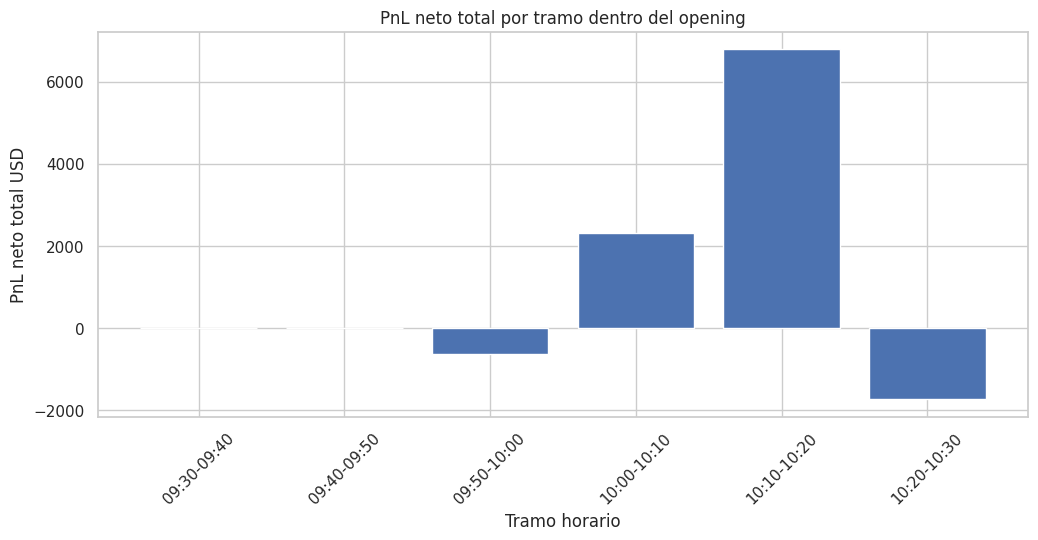

In [ ]:
# =========================================================
# 15.1.2. Desempeño intra-hora dentro del opening
# =========================================================

print("=" * 80)
print("DESEMPEÑO INTRA-HORA DENTRO DEL OPENING")
print("=" * 80)

df_ctx = df_equity.copy()

# ---------------------------------------------------------
# 1. Filtrar solo trades
# ---------------------------------------------------------

df_trades = df_ctx[df_ctx["signal"] != 0].copy()

# ---------------------------------------------------------
# 2. Crear bins de 10 minutos dentro del opening
# ---------------------------------------------------------
# Se asume que minute_of_day está expresado como minuto absoluto del día.
# 09:30 = 570
# 10:30 = 630

bins = [570, 580, 590, 600, 610, 620, 630]
labels = [
    "09:30-09:40",
    "09:40-09:50",
    "09:50-10:00",
    "10:00-10:10",
    "10:10-10:20",
    "10:20-10:30",
]

df_trades["opening_bin"] = pd.cut(
    df_trades["minute_of_day"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

# ---------------------------------------------------------
# 3. Métricas por tramo intra-hora
# ---------------------------------------------------------

df_pnl_by_bin = (
    df_trades
    .groupby("opening_bin", observed=False)
    .agg(
        n_trades=("pnl_usd_net", "count"),
        mean_pnl_usd=("pnl_usd_net", "mean"),
        total_pnl_usd=("pnl_usd_net", "sum"),
        win_rate=("pnl_usd_net", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

print("=" * 80)
print("RESULTADOS POR TRAMO DEL OPENING")
print("=" * 80)

display(df_pnl_by_bin)

# ---------------------------------------------------------
# 4. Visualización simple del PnL total por tramo
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.bar(df_pnl_by_bin["opening_bin"].astype(str), df_pnl_by_bin["total_pnl_usd"])
plt.title("PnL neto total por tramo dentro del opening")
plt.xlabel("Tramo horario")
plt.ylabel("PnL neto total USD")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Observaciones**

No hay actividad en los primeros 20 minutos (09:30–09:50).
El sistema no genera operaciones en ese tramo, lo que indica que los thresholds actuales filtran completamente esa fase inicial.

El tramo 09:50–10:00 presenta pérdidas.
Tiene pocas operaciones, bajo porcentaje de acierto (37%) y resultado negativo. Es una zona de baja calidad.

El tramo 10:00–10:20 concentra el rendimiento positivo.
En particular:

* 10:00–10:10: buen desempeño, positivo y relativamente estable
* 10:10–10:20: el mejor tramo, mayor PnL total, mayor promedio por trade y mejor tasa de acierto (~60%)

En este rango se encuentra el núcleo del desempeño del sistema.

El tramo 10:20–10:30 vuelve a ser negativo.
A pesar de tener muchas operaciones, presenta:

* pérdida total significativa
* bajo porcentaje de acierto (~37%)

Esto indica que el modelo pierde efectividad hacia el final del opening.

---

Conclusión

El rendimiento del sistema está claramente concentrado en una ventana específica:

10:00 – 10:20

Fuera de ese rango:

* antes: no opera o presenta pérdidas
* después: presenta pérdidas

---

Implicación directa

El drawdown observado proviene principalmente de:

* operaciones en 09:50–10:00
* operaciones en 10:20–10:30

---

Siguiente paso lógico

Esto permite definir una mejora inmediata:

restringir la operativa a la ventana:

10:00 – 10:20

Antes de aplicar filtros más complejos, este ajuste puede:

* eliminar operaciones de baja calidad
* reducir el drawdown
* mejorar la estabilidad del sistema


#### Análisis ajustado a 10:00 a 10:20

CÁLCULO DE PnL - GRU
Costo estimado por trade: 3.50 USD
RESULTADOS PnL - SIN FILTRO vs FILTRO TEMPORAL


,strategy,filter,threshold_long,threshold_short,n_trades,mean_pnl_points,total_pnl_points,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net
0,balanced,10:00_10:20,0.40,0.45,212,23.251179,4929.25,9858.5,9116.5,46.502358,43.002358,0.575472,0.575472
1,balanced,sin_filtro,0.40,0.45,309,12.675566,3916.75,7833.5,6752.0,25.351133,21.851133,0.514563,0.511327
2,baseline,10:00_10:20,0.40,0.40,642,4.621106,2966.75,5933.5,3686.5,9.242212,5.742212,0.485981,0.482866
3,conservative,10:00_10:20,0.41,0.50,120,8.954167,1074.50,2149.0,1729.0,17.908333,14.408333,0.500000,0.500000
4,high_precision,10:00_10:20,0.41,0.56,120,8.954167,1074.50,2149.0,1729.0,17.908333,14.408333,0.500000,0.500000
5,baseline,sin_filtro,0.40,0.40,916,2.474072,2266.25,4532.5,1326.5,4.948144,1.448144,0.465066,0.459607
6,high_precision,sin_filtro,0.41,0.56,188,1.686170,317.00,634.0,-24.0,3.372340,-0.127660,0.462766,0.457447
7,conservative,sin_filtro,0.41,0.50,188,1.686170,317.00,634.0,-24.0,3.372340,-0.127660,0.462766,0.457447


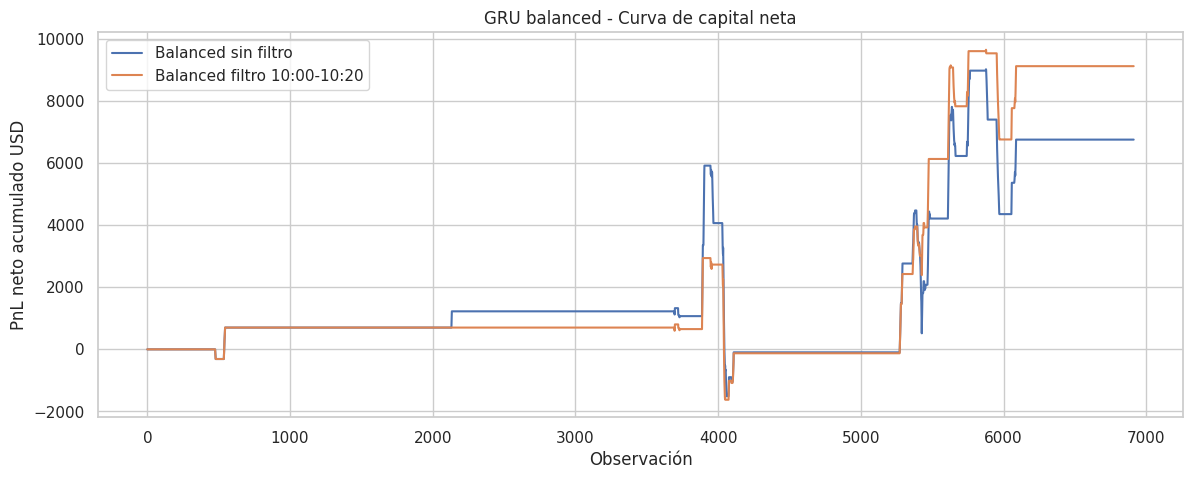

In [ ]:
# =========================================================
# 13. Cálculo de PnL - GRU configuraciones
#     con y sin filtro temporal intra-opening
# =========================================================

print("=" * 80)
print("CÁLCULO DE PnL - GRU")
print("=" * 80)

# =========================================================
# 13.1. Parámetros económicos
# =========================================================

POINT_VALUE_USD = 2.0      # MNQ: 1 punto = 2 USD por contrato
N_CONTRACTS = 1

COMMISSION_PER_SIDE_USD = 1.25
SLIPPAGE_POINTS_PER_SIDE = 0.25

COST_PER_TRADE_USD = (
    2 * COMMISSION_PER_SIDE_USD +
    2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
) * N_CONTRACTS

print(f"Costo estimado por trade: {COST_PER_TRADE_USD:.2f} USD")


# =========================================================
# 13.2. Función para construir señales
# =========================================================

def build_signal(df, thr_long, thr_short):
    """
    Genera señal operativa:
        1  = long
       -1  = short
        0  = no trade
    """

    p_long = df["gru_proba_1"].values
    p_short = df["gru_proba_-1"].values

    signal = np.zeros(len(df), dtype=int)

    long_mask = p_long >= thr_long
    short_mask = p_short >= thr_short

    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    conflict = long_mask & short_mask
    signal[conflict & (p_long > p_short)] = 1
    signal[conflict & (p_short > p_long)] = -1

    return signal


# =========================================================
# 13.3. Función para calcular PnL
# =========================================================

def compute_pnl_metrics(df, signal_col, strategy_name):
    """
    Calcula métricas económicas usando:
        pnl_points = signal * delta_30
        pnl_usd_gross = pnl_points * valor del punto
        pnl_usd_net = pnl_usd_gross - costos por trade
    """

    tmp = df.copy()

    tmp["trade"] = tmp[signal_col] != 0

    tmp["pnl_points"] = tmp[signal_col] * tmp["delta_30"]

    tmp["pnl_usd_gross"] = (
        tmp["pnl_points"] * POINT_VALUE_USD * N_CONTRACTS
    )

    tmp["cost_usd"] = np.where(
        tmp["trade"],
        COST_PER_TRADE_USD,
        0.0
    )

    tmp["pnl_usd_net"] = tmp["pnl_usd_gross"] - tmp["cost_usd"]

    tmp["cum_pnl_usd_gross"] = tmp["pnl_usd_gross"].cumsum()
    tmp["cum_pnl_usd_net"] = tmp["pnl_usd_net"].cumsum()

    trades = tmp[tmp["trade"]].copy()

    if len(trades) == 0:
        return tmp, {
            "strategy": strategy_name,
            "n_trades": 0,
            "mean_pnl_points": np.nan,
            "total_pnl_points": 0.0,
            "gross_pnl_usd": 0.0,
            "net_pnl_usd": 0.0,
            "mean_gross_pnl_usd": np.nan,
            "mean_net_pnl_usd": np.nan,
            "win_rate_gross": np.nan,
            "win_rate_net": np.nan,
        }

    metrics = {
        "strategy": strategy_name,
        "n_trades": len(trades),
        "mean_pnl_points": trades["pnl_points"].mean(),
        "total_pnl_points": trades["pnl_points"].sum(),
        "gross_pnl_usd": trades["pnl_usd_gross"].sum(),
        "net_pnl_usd": trades["pnl_usd_net"].sum(),
        "mean_gross_pnl_usd": trades["pnl_usd_gross"].mean(),
        "mean_net_pnl_usd": trades["pnl_usd_net"].mean(),
        "win_rate_gross": (trades["pnl_usd_gross"] > 0).mean(),
        "win_rate_net": (trades["pnl_usd_net"] > 0).mean(),
    }

    return tmp, metrics


# =========================================================
# 13.4. Configuraciones GRU a evaluar
# =========================================================

configs = [
    ("baseline", 0.40, 0.40),
    ("balanced", 0.40, 0.45),
    ("conservative", 0.41, 0.50),
    ("high_precision", 0.41, 0.56),
]


# =========================================================
# 13.5. Evaluación sin filtro temporal
# =========================================================

results_no_filter = []
equity_curves = {}

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal"] = build_signal(
        df=df_tmp,
        thr_long=thr_l,
        thr_short=thr_s,
    )

    df_pnl_tmp, metrics = compute_pnl_metrics(
        df=df_tmp,
        signal_col="signal",
        strategy_name=name,
    )

    metrics["filter"] = "sin_filtro"
    metrics["threshold_long"] = thr_l
    metrics["threshold_short"] = thr_s

    results_no_filter.append(metrics)
    equity_curves[(name, "sin_filtro")] = df_pnl_tmp


# =========================================================
# 13.6. Evaluación con filtro temporal 10:00-10:20
# =========================================================

results_time_filter = []

TIME_START = 600   # 10:00
TIME_END = 620     # 10:20

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal_raw_strategy"] = build_signal(
        df=df_tmp,
        thr_long=thr_l,
        thr_short=thr_s,
    )

    valid_time_mask = (
        (df_tmp["minute_of_day"] >= TIME_START) &
        (df_tmp["minute_of_day"] < TIME_END)
    )

    # No se eliminan filas: solo se anulan señales fuera del rango horario
    df_tmp["signal_time_filter"] = np.where(
        valid_time_mask,
        df_tmp["signal_raw_strategy"],
        0
    )

    df_pnl_tmp, metrics = compute_pnl_metrics(
        df=df_tmp,
        signal_col="signal_time_filter",
        strategy_name=name,
    )

    metrics["filter"] = "10:00_10:20"
    metrics["threshold_long"] = thr_l
    metrics["threshold_short"] = thr_s

    results_time_filter.append(metrics)
    equity_curves[(name, "10:00_10:20")] = df_pnl_tmp


# =========================================================
# 13.7. Resultados comparativos
# =========================================================

df_pnl_comparison = pd.DataFrame(
    results_no_filter + results_time_filter
)

df_pnl_comparison = df_pnl_comparison[
    [
        "strategy",
        "filter",
        "threshold_long",
        "threshold_short",
        "n_trades",
        "mean_pnl_points",
        "total_pnl_points",
        "gross_pnl_usd",
        "net_pnl_usd",
        "mean_gross_pnl_usd",
        "mean_net_pnl_usd",
        "win_rate_gross",
        "win_rate_net",
    ]
].sort_values(
    by="net_pnl_usd",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("RESULTADOS PnL - SIN FILTRO vs FILTRO TEMPORAL")
print("=" * 80)

display(df_pnl_comparison)


# =========================================================
# 13.8. Curva de capital para GRU balanced
# =========================================================

df_balanced_no_filter = equity_curves[("balanced", "sin_filtro")]
df_balanced_time_filter = equity_curves[("balanced", "10:00_10:20")]

plt.figure(figsize=(14, 5))

plt.plot(
    df_balanced_no_filter["cum_pnl_usd_net"].values,
    label="Balanced sin filtro"
)

plt.plot(
    df_balanced_time_filter["cum_pnl_usd_net"].values,
    label="Balanced filtro 10:00-10:20"
)

plt.title("GRU balanced - Curva de capital neta")
plt.xlabel("Observación")
plt.ylabel("PnL neto acumulado USD")
plt.legend()
plt.grid(True)
plt.show()

## **15.2. Filtro de calidad de operaciones**

En este punto se busca mejorar la calidad de las señales sin modificar el modelo, seleccionando únicamente aquellas operaciones con mayor probabilidad de éxito.

Aunque el filtro temporal ya redujo gran parte del ruido, todavía existen operaciones dentro del rango 10:00–10:20 que no aportan valor o incluso generan pérdidas.

El objetivo es identificar qué características hacen que una operación sea “buena” y utilizar esa información para filtrar el resto. Esto permite:

* aumentar la ganancia por operación
* mejorar la tasa de acierto
* reducir aún más el drawdown

---

## Primer análisis recomendado

👉 Empezar por lo más directo:

### Filtro por nivel de confianza (probabilidad del modelo)

Es decir:

* operar solo cuando la probabilidad es alta
* ignorar señales débiles

---

## Qué vamos a hacer

1. Tomar solo trades dentro de **10:00–10:20**
2. Analizar el desempeño según nivel de probabilidad (`proba_1` o `proba_-1`)
3. Ver si las probabilidades más altas realmente generan mejores resultados

---

## Por qué este paso es clave

Porque ahora queremos validar:

```text
¿el modelo sabe cuándo está más seguro?
```

Si la respuesta es sí:

👉 podés quedarte solo con esas señales
👉 y mejorar mucho el sistema sin cambiar nada más

---

Si estás de acuerdo, el siguiente bloque es:

👉 **15.2.1 Desempeño por nivel de probabilidad (confidence bins)**

y ahí vamos a ver si las señales “más confiables” realmente ganan más dinero.


### **15.2.1 Desempeño por nivel de probabilidad (confidence bins)**


En este punto se analiza cómo varía el resultado económico de la estrategia según el nivel de confianza del modelo en cada operación.

La confianza puede interpretarse como qué tan seguro está el modelo de que una señal es correcta. En términos prácticos, esto se refleja en las probabilidades (`proba_1` para long y `proba_-1` para short).

El objetivo es verificar si las operaciones con mayor probabilidad efectivamente generan mejores resultados. Si esto se cumple, es posible filtrar señales de baja confianza y conservar únicamente aquellas con mayor calidad, mejorando así el rendimiento del sistema sin modificar el modelo.


DESEMPEÑO POR NIVEL DE PROBABILIDAD
RESULTADOS POR RANGO DE PROBABILIDAD


,proba_bin,n_trades,mean_pnl_usd,total_pnl_usd,win_rate
0,0.40-0.45,145,27.193103,3943.0,0.544828
1,0.45-0.50,67,77.216418,5173.5,0.641791
2,0.50-0.55,0,NaN,0.0,NaN
3,0.55-0.60,0,NaN,0.0,NaN
4,0.60+,0,NaN,0.0,NaN


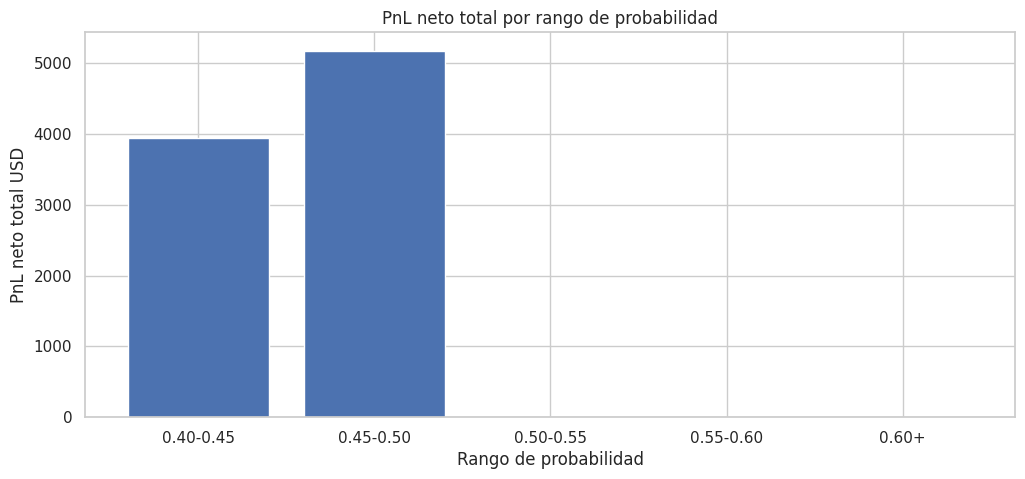

In [ ]:
# =========================================================
# 15.2.1. Desempeño por nivel de probabilidad
# =========================================================

print("=" * 80)
print("DESEMPEÑO POR NIVEL DE PROBABILIDAD")
print("=" * 80)

# =========================================================
# 15.2.1.1. Dataset base: GRU balanced + filtro temporal
# =========================================================

df_quality = df_test_gru_cmp.copy()

thr_long = 0.40
thr_short = 0.45

TIME_START = 600   # 10:00
TIME_END = 620     # 10:20

df_quality["signal"] = build_signal(
    df=df_quality,
    thr_long=thr_long,
    thr_short=thr_short,
)

time_mask = (
    (df_quality["minute_of_day"] >= TIME_START) &
    (df_quality["minute_of_day"] < TIME_END)
)

df_quality["signal"] = np.where(time_mask, df_quality["signal"], 0)
df_quality["trade"] = df_quality["signal"] != 0

# =========================================================
# 15.2.1.2. Probabilidad usada para cada trade
# =========================================================

df_quality["signal_proba"] = np.where(
    df_quality["signal"] == 1,
    df_quality["gru_proba_1"],
    np.where(
        df_quality["signal"] == -1,
        df_quality["gru_proba_-1"],
        np.nan,
    )
)

# =========================================================
# 15.2.1.3. PnL neto por operación
# =========================================================

df_quality["pnl_points"] = df_quality["signal"] * df_quality["delta_30"]
df_quality["pnl_usd_gross"] = df_quality["pnl_points"] * POINT_VALUE_USD * N_CONTRACTS

df_quality["cost_usd"] = np.where(
    df_quality["trade"],
    COST_PER_TRADE_USD,
    0.0,
)

df_quality["pnl_usd_net"] = df_quality["pnl_usd_gross"] - df_quality["cost_usd"]

# =========================================================
# 15.2.1.4. Filtrar solo trades
# =========================================================

df_quality_trades = df_quality[df_quality["trade"]].copy()

# =========================================================
# 15.2.1.5. Agrupar por rangos de probabilidad
# =========================================================

proba_bins = [0.40, 0.45, 0.50, 0.55, 0.60, 1.00]
proba_labels = [
    "0.40-0.45",
    "0.45-0.50",
    "0.50-0.55",
    "0.55-0.60",
    "0.60+",
]

df_quality_trades["proba_bin"] = pd.cut(
    df_quality_trades["signal_proba"],
    bins=proba_bins,
    labels=proba_labels,
    right=False,
    include_lowest=True,
)

df_quality_by_proba = (
    df_quality_trades
    .groupby("proba_bin", observed=False)
    .agg(
        n_trades=("pnl_usd_net", "count"),
        mean_pnl_usd=("pnl_usd_net", "mean"),
        total_pnl_usd=("pnl_usd_net", "sum"),
        win_rate=("pnl_usd_net", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

print("=" * 80)
print("RESULTADOS POR RANGO DE PROBABILIDAD")
print("=" * 80)

display(df_quality_by_proba)

# =========================================================
# 15.2.1.6. Visualización
# =========================================================

plt.figure(figsize=(12, 5))
plt.bar(
    df_quality_by_proba["proba_bin"].astype(str),
    df_quality_by_proba["total_pnl_usd"],
)
plt.title("PnL neto total por rango de probabilidad")
plt.xlabel("Rango de probabilidad")
plt.ylabel("PnL neto total USD")
plt.grid(True)
plt.show()

**Observaciones**

* Todas las operaciones se concentran entre probabilidades de **0.40 y 0.50**.
* No hay operaciones por encima de **0.50**, lo que confirma que el GRU no trabaja con señales de probabilidad extrema.
* El rango **0.45–0.50** es claramente superior:

  * menos trades: 67
  * mayor ganancia promedio: 77.2 USD
  * mayor win rate: 64.2%
  * mayor PnL total: 5173.5 USD
* El rango **0.40–0.45** también es rentable, pero con menor calidad:

  * más trades: 145
  * menor ganancia promedio: 27.2 USD
  * menor win rate: 54.5%

Conclusión

El modelo sí diferencia calidad de señal: cuando la probabilidad sube de **0.45**, las operaciones son mucho mejores.

Siguiente paso lógico: probar un filtro de calidad que opere solo señales con probabilidad **>= 0.45** dentro de 10:00–10:20.


### **15.2.2 Aplicación de filtro por probabilidad mínima**

En este punto se implementa de forma operativa el análisis realizado previamente sobre los niveles de probabilidad.

Se observó que las operaciones con probabilidades superiores a 0.45 presentan una mejora significativa en términos de rentabilidad, tasa de acierto y ganancia por trade. A partir de este hallazgo, se introduce un criterio adicional de selección que permite filtrar únicamente aquellas señales con mayor calidad.

La estrategia pasa entonces a operar bajo dos condiciones simultáneas:

* dentro de la ventana temporal óptima (10:00–10:20)
* con una probabilidad mínima definida (por ejemplo, ≥ 0.45)

El objetivo es evaluar si esta combinación permite mejorar aún más el rendimiento del sistema, reduciendo el número de operaciones pero aumentando su efectividad y estabilidad.

Este paso representa la transición desde un análisis descriptivo hacia una regla de decisión concreta, orientada a optimizar el comportamiento económico de la estrategia.


FILTRO POR PROBABILIDAD MÍNIMA
RESULTADOS CON FILTRO DE PROBABILIDAD


,strategy,n_trades,mean_pnl_points,total_pnl_points,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net
0,GRU balanced + time + proba filter,67,40.358209,2704.0,5408.0,5173.5,80.716418,77.216418,0.641791,0.641791


COMPARACIÓN FILTRO TEMPORAL vs FILTRO TEMPORAL + PROBABILIDAD


,strategy,n_trades,net_pnl_usd,mean_net_pnl_usd,win_rate_net
0,GRU balanced + time filter,212,9116.5,43.002358,0.575472
1,GRU balanced + time + proba filter,67,5173.5,77.216418,0.641791


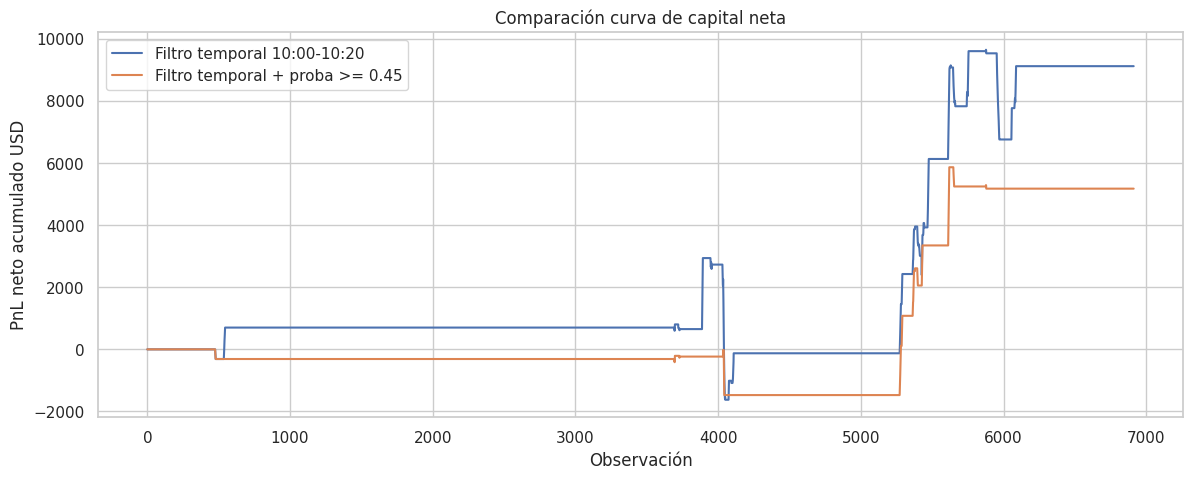

In [ ]:
# =========================================================
# 15.2.2. Aplicación de filtro por probabilidad mínima
# =========================================================

print("=" * 80)
print("FILTRO POR PROBABILIDAD MÍNIMA")
print("=" * 80)

# =========================================================
# 15.2.2.1. Parámetros de la estrategia
# =========================================================

thr_long = 0.40
thr_short = 0.45

TIME_START = 600   # 10:00
TIME_END = 620     # 10:20

MIN_SIGNAL_PROBA = 0.45


# =========================================================
# 15.2.2.2. Construcción de señal base
# =========================================================

df_quality_filter = df_test_gru_cmp.copy()

df_quality_filter["signal_base"] = build_signal(
    df=df_quality_filter,
    thr_long=thr_long,
    thr_short=thr_short,
)

# Probabilidad asociada a la dirección de la señal
df_quality_filter["signal_proba"] = np.where(
    df_quality_filter["signal_base"] == 1,
    df_quality_filter["gru_proba_1"],
    np.where(
        df_quality_filter["signal_base"] == -1,
        df_quality_filter["gru_proba_-1"],
        np.nan,
    )
)


# =========================================================
# 15.2.2.3. Aplicación de filtros
# =========================================================

time_mask = (
    (df_quality_filter["minute_of_day"] >= TIME_START) &
    (df_quality_filter["minute_of_day"] < TIME_END)
)

proba_mask = df_quality_filter["signal_proba"] >= MIN_SIGNAL_PROBA

df_quality_filter["signal_filtered"] = np.where(
    time_mask & proba_mask,
    df_quality_filter["signal_base"],
    0,
)


# =========================================================
# 15.2.2.4. Cálculo de PnL
# =========================================================

df_quality_filter, metrics_quality_filter = compute_pnl_metrics(
    df=df_quality_filter,
    signal_col="signal_filtered",
    strategy_name="GRU balanced + time + proba filter",
)

df_metrics_quality_filter = pd.DataFrame([metrics_quality_filter])

print("=" * 80)
print("RESULTADOS CON FILTRO DE PROBABILIDAD")
print("=" * 80)

display(df_metrics_quality_filter)


# =========================================================
# 15.2.2.5. Comparación contra estrategia anterior
# =========================================================

comparison_rows = []

# Estrategia balanced con filtro temporal, sin filtro de probabilidad adicional
df_prev = equity_curves[("balanced", "10:00_10:20")].copy()
trades_prev = df_prev[df_prev["trade"]].copy()

comparison_rows.append({
    "strategy": "GRU balanced + time filter",
    "n_trades": len(trades_prev),
    "net_pnl_usd": trades_prev["pnl_usd_net"].sum(),
    "mean_net_pnl_usd": trades_prev["pnl_usd_net"].mean(),
    "win_rate_net": (trades_prev["pnl_usd_net"] > 0).mean(),
})

# Estrategia nueva con filtro de probabilidad
trades_new = df_quality_filter[df_quality_filter["trade"]].copy()

comparison_rows.append({
    "strategy": "GRU balanced + time + proba filter",
    "n_trades": len(trades_new),
    "net_pnl_usd": trades_new["pnl_usd_net"].sum(),
    "mean_net_pnl_usd": trades_new["pnl_usd_net"].mean(),
    "win_rate_net": (trades_new["pnl_usd_net"] > 0).mean(),
})

df_quality_filter_comparison = pd.DataFrame(comparison_rows)

print("=" * 80)
print("COMPARACIÓN FILTRO TEMPORAL vs FILTRO TEMPORAL + PROBABILIDAD")
print("=" * 80)

display(df_quality_filter_comparison)


# =========================================================
# 15.2.2.6. Curva de capital comparativa
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df_prev["cum_pnl_usd_net"].values,
    label="Filtro temporal 10:00-10:20",
)

plt.plot(
    df_quality_filter["cum_pnl_usd_net"].values,
    label="Filtro temporal + proba >= 0.45",
)

plt.title("Comparación curva de capital neta")
plt.xlabel("Observación")
plt.ylabel("PnL neto acumulado USD")
plt.legend()
plt.grid(True)
plt.show()

**Observaciones**

El filtro por probabilidad reduce significativamente la cantidad de operaciones.

* pasa de 212 a 67 trades
* es decir, elimina casi el 70% de las operaciones

Esto confirma que solo una pequeña parte de las señales tiene alta calidad.

---

La calidad de las operaciones mejora de forma clara.

* ganancia promedio por trade: 43 → 77 USD
* win rate: 57% → 64%

En términos simples:

* menos operaciones
* pero mucho mejores

---

El beneficio total disminuye.

* pasa de 9116 USD a 5173 USD

Esto ocurre porque:

* aunque cada trade es mejor
* hay muchas menos oportunidades

---

Interpretación

El filtro está haciendo exactamente lo esperado:

* elimina operaciones de menor calidad
* conserva solo las mejores señales

Pero introduce un trade-off claro:

```text id="fwc6qm"
más calidad vs menos volumen
```

---

Lectura en términos reales

* sin filtro: sistema más activo, mayor ingreso total
* con filtro: sistema más selectivo, más preciso, pero menor ingreso

---

Conclusión

El filtro por probabilidad mejora la calidad del sistema, pero reduce su capacidad de generación de ingresos.

Esto no es un problema, sino una decisión estratégica:

* si se busca estabilidad → filtro más estricto
* si se busca maximizar ingresos → mantener mayor volumen

---





### **15.2.3 Optimización del threshold de probabilidad**

**Introducción**

En este punto se busca encontrar el nivel óptimo de probabilidad mínima para filtrar operaciones, equilibrando la cantidad de trades con su calidad.

En el paso anterior se observó que aumentar el umbral de probabilidad mejora la calidad de las operaciones, pero reduce significativamente el volumen. Por lo tanto, el objetivo ahora es identificar un valor intermedio que permita maximizar el beneficio total sin deteriorar en exceso la estabilidad del sistema.

Este análisis se realiza evaluando múltiples valores de probabilidad mínima dentro de un rango definido, manteniendo constante el filtro temporal (10:00–10:20) y la configuración del modelo.


OPTIMIZACIÓN DEL THRESHOLD DE PROBABILIDAD
TOP RESULTADOS


,strategy,n_trades,mean_pnl_points,total_pnl_points,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net,proba_threshold
0,thr_0.4,212,23.251179,4929.25,9858.5,9116.5,46.502358,43.002358,0.575472,0.575472,0.40
1,thr_0.41,169,20.852071,3524.00,7048.0,6456.5,41.704142,38.204142,0.562130,0.562130,0.41
2,thr_0.45,67,40.358209,2704.00,5408.0,5173.5,80.716418,77.216418,0.641791,0.641791,0.45
3,thr_0.44,83,31.219880,2591.25,5182.5,4892.0,62.439759,58.939759,0.590361,0.590361,0.44
4,thr_0.42,126,16.474206,2075.75,4151.5,3710.5,32.948413,29.448413,0.515873,0.515873,0.42
5,thr_0.43,104,17.209135,1789.75,3579.5,3215.5,34.418269,30.918269,0.519231,0.519231,0.43
6,thr_0.46,24,42.052083,1009.25,2018.5,1934.5,84.104167,80.604167,0.625000,0.625000,0.46
7,thr_0.47,5,34.800000,174.00,348.0,330.5,69.600000,66.100000,0.600000,0.600000,0.47
8,thr_0.48,0,NaN,0.00,0.0,0.0,NaN,NaN,NaN,NaN,0.48
9,thr_0.49,0,NaN,0.00,0.0,0.0,NaN,NaN,NaN,NaN,0.49


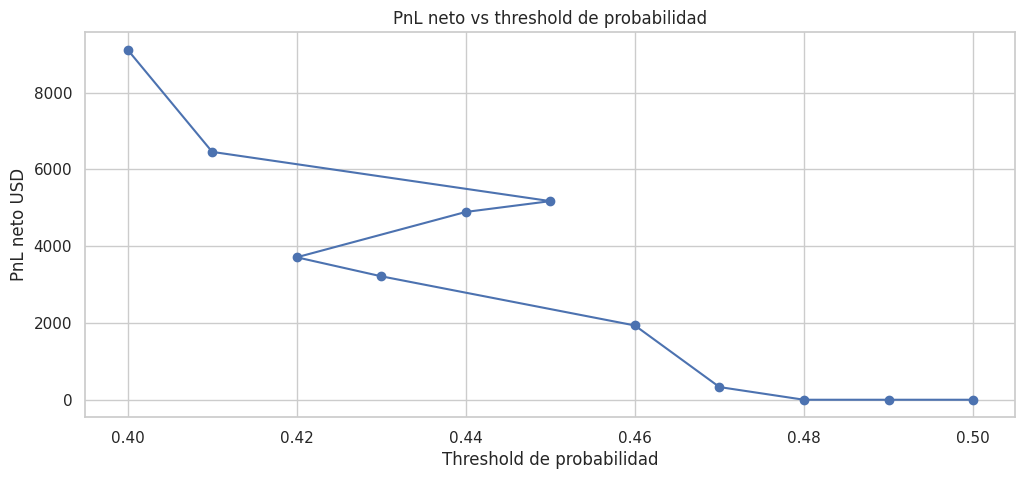

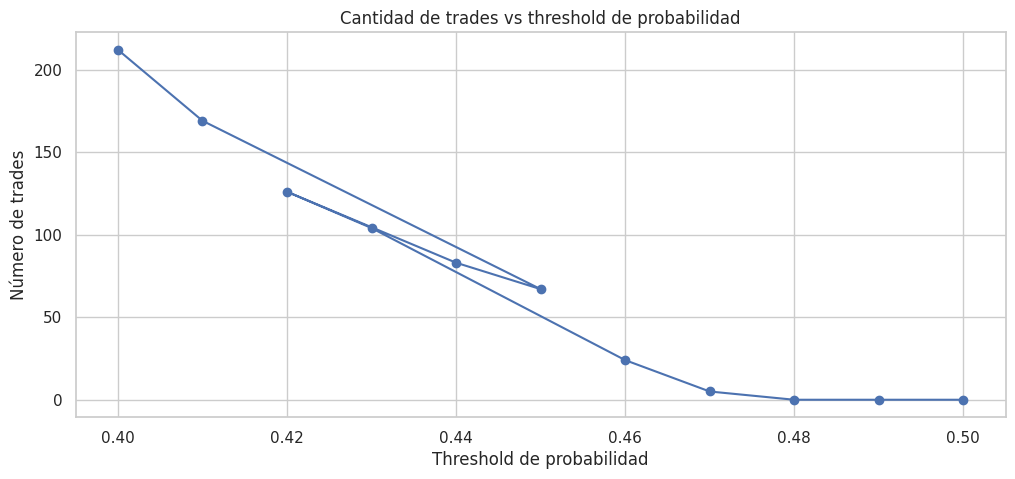

In [ ]:
# =========================================================
# 15.2.3. Optimización del threshold de probabilidad
# =========================================================

print("=" * 80)
print("OPTIMIZACIÓN DEL THRESHOLD DE PROBABILIDAD")
print("=" * 80)

# ---------------------------------------------------------
# Parámetros base
# ---------------------------------------------------------

thr_long = 0.40
thr_short = 0.45

TIME_START = 600
TIME_END = 620

# Rango de thresholds a evaluar
proba_thresholds = np.round(np.arange(0.40, 0.51, 0.01), 2)

results = []

# ---------------------------------------------------------
# Loop de evaluación
# ---------------------------------------------------------

for p_thr in proba_thresholds:

    df_tmp = df_test_gru_cmp.copy()

    # Señal base
    df_tmp["signal_base"] = build_signal(df_tmp, thr_long, thr_short)

    # Probabilidad asociada
    df_tmp["signal_proba"] = np.where(
        df_tmp["signal_base"] == 1,
        df_tmp["gru_proba_1"],
        np.where(
            df_tmp["signal_base"] == -1,
            df_tmp["gru_proba_-1"],
            np.nan
        )
    )

    # Filtros
    time_mask = (
        (df_tmp["minute_of_day"] >= TIME_START) &
        (df_tmp["minute_of_day"] < TIME_END)
    )

    proba_mask = df_tmp["signal_proba"] >= p_thr

    df_tmp["signal_filtered"] = np.where(
        time_mask & proba_mask,
        df_tmp["signal_base"],
        0
    )

    # PnL
    df_tmp, metrics = compute_pnl_metrics(
        df_tmp,
        signal_col="signal_filtered",
        strategy_name=f"thr_{p_thr}"
    )

    metrics["proba_threshold"] = p_thr
    results.append(metrics)

# ---------------------------------------------------------
# Resultados
# ---------------------------------------------------------

df_proba_opt = pd.DataFrame(results)

df_proba_opt = df_proba_opt.sort_values(
    by="net_pnl_usd",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("TOP RESULTADOS")
print("=" * 80)

display(df_proba_opt.head(15))

# ---------------------------------------------------------
# Visualización
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(
    df_proba_opt["proba_threshold"],
    df_proba_opt["net_pnl_usd"],
    marker="o"
)
plt.title("PnL neto vs threshold de probabilidad")
plt.xlabel("Threshold de probabilidad")
plt.ylabel("PnL neto USD")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    df_proba_opt["proba_threshold"],
    df_proba_opt["n_trades"],
    marker="o"
)
plt.title("Cantidad de trades vs threshold de probabilidad")
plt.xlabel("Threshold de probabilidad")
plt.ylabel("Número de trades")
plt.grid(True)
plt.show()

Observaciones

El máximo beneficio se obtiene sin aplicar filtro adicional de probabilidad.

* threshold 0.40 (solo filtro temporal) → ~9,116 USD
* es el mejor resultado en términos de dinero total

Esto indica que el sistema ya estaba bien calibrado con ese nivel.

---

Al aumentar el threshold, el beneficio cae rápidamente.

* 0.41 → ~6,456 USD
* 0.44–0.45 → ~4,800 – 5,100 USD
* > 0.46 → el sistema prácticamente deja de operar

Esto muestra que se están eliminando demasiadas oportunidades.

---

La calidad mejora, pero no compensa la pérdida de volumen.

Ejemplo:

* 0.45 → mejor win rate (~64%)
* pero mucho menos PnL total (~5,173 USD vs ~9,116 USD)

En simple:

* mejores trades
* pero muy pocos

---

El sistema depende del volumen de operaciones.

* gran parte del beneficio total viene de acumular muchas operaciones razonablemente buenas
* no de pocas operaciones “perfectas”

---

Zona intermedia (0.43–0.45)

* mejora la calidad
* pero reduce demasiado el ingreso

No hay un punto donde:

* suba el PnL total
* y mejore significativamente la estabilidad

---

Conclusión

```text
El mejor equilibrio para este sistema es NO aplicar filtro adicional de probabilidad.
```

El filtro temporal ya captura la mayor mejora.

Agregar filtro de probabilidad:

* mejora métricas como win rate
* pero reduce el beneficio total

---

Decisión operativa

Configuración recomendada:

* filtro temporal: 10:00–10:20
* threshold_long = 0.40
* threshold_short = 0.45
* sin filtro adicional de probabilidad

---

Interpretación final

```text
El modelo no necesita más filtros de calidad.
Ya está funcionando en su punto óptimo con el filtro temporal.
```

## **15.3 Tamaño de posición**


**Introducción**

Hasta este punto, la estrategia ha sido evaluada utilizando un tamaño de posición fijo, es decir, operando siempre con la misma cantidad de contratos en cada trade.

Sin embargo, en un entorno real de trading, no todas las operaciones deberían tener el mismo peso. Algunas señales presentan mayor calidad o mayor probabilidad de éxito, mientras que otras son más débiles. Ajustar el tamaño de la posición permite asignar más capital a las mejores oportunidades y menos a las más riesgosas.

El objetivo de este punto es evaluar cómo impacta el tamaño de la posición en el rendimiento económico del sistema, manteniendo constante la lógica de generación de señales.

---

**Enfoque inicial**

Se comenzará con un esquema simple y controlado:

* mantener la estrategia base:

  * filtro temporal: 10:00–10:20
  * thresholds: 0.40 / 0.45

* evaluar distintos tamaños de posición fijos:

  * 1 contrato
  * 2 contratos
  * 3 contratos
  * 4 contratos

Esto permite entender cómo escala el sistema en términos de:

* beneficio total
* drawdown
* riesgo asumido

---

**Idea clave**

```text
Si el sistema es robusto, al aumentar el tamaño de posición:
- el beneficio debería escalar proporcionalmente
- pero también lo hará el riesgo
```

ANÁLISIS DE TAMAÑO DE POSICIÓN
RESULTADOS POR TAMAÑO DE POSICIÓN


,contracts,n_trades,net_pnl_usd,mean_net_pnl_usd,win_rate_net,max_drawdown_usd,pnl_to_drawdown
0,1,212,9116.5,43.002358,0.575472,-4561.0,1.998794
1,2,212,18233.0,86.004717,0.575472,-9122.0,1.998794
2,3,212,27349.5,129.007075,0.575472,-13683.0,1.998794
3,4,212,36466.0,172.009434,0.575472,-18244.0,1.998794


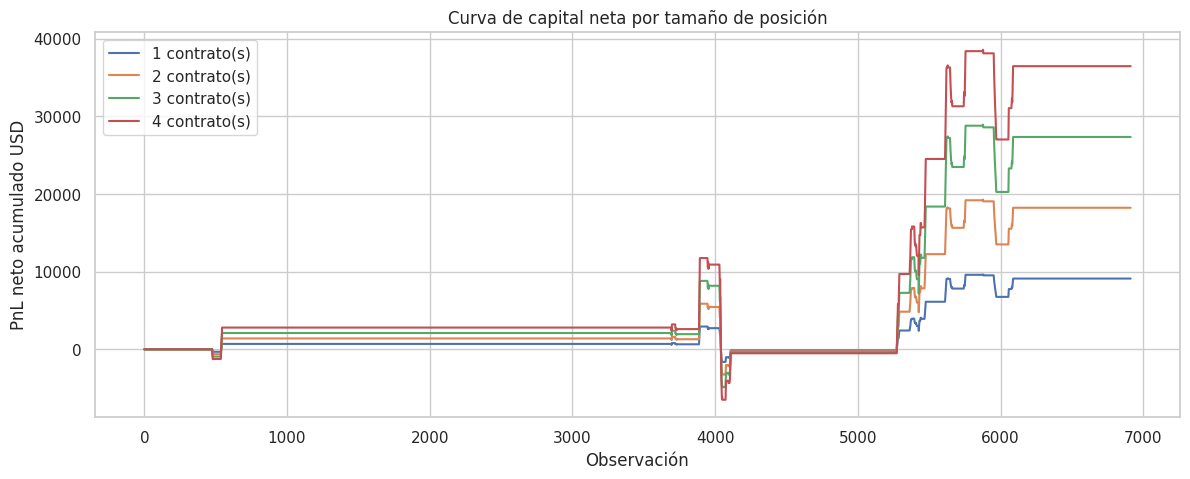

In [ ]:
# =========================================================
# 15.3. Tamaño de posición
# =========================================================

print("=" * 80)
print("ANÁLISIS DE TAMAÑO DE POSICIÓN")
print("=" * 80)

# =========================================================
# 15.3.1. Parámetros base de la estrategia
# =========================================================

thr_long = 0.40
thr_short = 0.45

TIME_START = 600   # 10:00
TIME_END = 620     # 10:20

POINT_VALUE_USD = 2.0
COMMISSION_PER_SIDE_USD = 1.25
SLIPPAGE_POINTS_PER_SIDE = 0.25

contracts_list = [1, 2, 3, 4]


# =========================================================
# 15.3.2. Construcción de señal base
# =========================================================

df_position = df_test_gru_cmp.copy()

df_position["signal"] = build_signal(
    df=df_position,
    thr_long=thr_long,
    thr_short=thr_short,
)

time_mask = (
    (df_position["minute_of_day"] >= TIME_START) &
    (df_position["minute_of_day"] < TIME_END)
)

df_position["signal"] = np.where(
    time_mask,
    df_position["signal"],
    0,
)

df_position["trade"] = df_position["signal"] != 0


# =========================================================
# 15.3.3. Evaluación por número de contratos
# =========================================================

position_results = []

for n_contracts in contracts_list:

    df_tmp = df_position.copy()

    cost_per_trade_usd = (
        2 * COMMISSION_PER_SIDE_USD +
        2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
    ) * n_contracts

    df_tmp["pnl_points"] = df_tmp["signal"] * df_tmp["delta_30"]

    df_tmp["pnl_usd_gross"] = (
        df_tmp["pnl_points"] * POINT_VALUE_USD * n_contracts
    )

    df_tmp["cost_usd"] = np.where(
        df_tmp["trade"],
        cost_per_trade_usd,
        0.0,
    )

    df_tmp["pnl_usd_net"] = df_tmp["pnl_usd_gross"] - df_tmp["cost_usd"]

    df_tmp["cum_pnl_usd_net"] = df_tmp["pnl_usd_net"].cumsum()

    df_tmp["equity_peak"] = df_tmp["cum_pnl_usd_net"].cummax()
    df_tmp["drawdown_usd"] = df_tmp["cum_pnl_usd_net"] - df_tmp["equity_peak"]

    trades = df_tmp[df_tmp["trade"]].copy()

    position_results.append({
        "contracts": n_contracts,
        "n_trades": len(trades),
        "net_pnl_usd": trades["pnl_usd_net"].sum(),
        "mean_net_pnl_usd": trades["pnl_usd_net"].mean(),
        "win_rate_net": (trades["pnl_usd_net"] > 0).mean(),
        "max_drawdown_usd": df_tmp["drawdown_usd"].min(),
        "pnl_to_drawdown": (
            trades["pnl_usd_net"].sum() / abs(df_tmp["drawdown_usd"].min())
            if df_tmp["drawdown_usd"].min() < 0
            else np.nan
        ),
    })

df_position_size_results = pd.DataFrame(position_results)

print("=" * 80)
print("RESULTADOS POR TAMAÑO DE POSICIÓN")
print("=" * 80)

display(df_position_size_results)


# =========================================================
# 15.3.4. Curvas de capital por número de contratos
# =========================================================

plt.figure(figsize=(14, 5))

for n_contracts in contracts_list:

    df_tmp = df_position.copy()

    cost_per_trade_usd = (
        2 * COMMISSION_PER_SIDE_USD +
        2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
    ) * n_contracts

    df_tmp["pnl_points"] = df_tmp["signal"] * df_tmp["delta_30"]
    df_tmp["pnl_usd_gross"] = df_tmp["pnl_points"] * POINT_VALUE_USD * n_contracts

    df_tmp["cost_usd"] = np.where(
        df_tmp["trade"],
        cost_per_trade_usd,
        0.0,
    )

    df_tmp["pnl_usd_net"] = df_tmp["pnl_usd_gross"] - df_tmp["cost_usd"]
    df_tmp["cum_pnl_usd_net"] = df_tmp["pnl_usd_net"].cumsum()

    plt.plot(
        df_tmp["cum_pnl_usd_net"].values,
        label=f"{n_contracts} contrato(s)",
    )

plt.title("Curva de capital neta por tamaño de posición")
plt.xlabel("Observación")
plt.ylabel("PnL neto acumulado USD")
plt.legend()
plt.grid(True)
plt.show()

Observaciones

El sistema escala de forma lineal con el número de contratos.

* 1 contrato → ~9,116 USD
* 2 contratos → ~18,233 USD
* 4 contratos → ~36,466 USD

Esto indica que el modelo es consistente: al duplicar la exposición, se duplican las ganancias.

---

El riesgo también escala de forma proporcional.

* drawdown 1 contrato → ~ -4,561 USD
* drawdown 4 contratos → ~ -18,244 USD

Es decir:

```text
más contratos = más ganancia, pero también más riesgo
```

---

La calidad del sistema no cambia.

* win rate se mantiene (~57.5%)
* ganancia promedio por trade escala proporcionalmente
* ratio PnL / drawdown se mantiene (~2.0)

Esto confirma que:

```text
el modelo es estable, no se deteriora al escalar
```

---

Interpretación en términos reales

Con 1 contrato:

* ~800 USD/mes
* drawdown manejable

Con 4 contratos:

* ~3,200 USD/mes
* pero drawdown mucho más exigente

---

Conclusión

El sistema ya está optimizado en términos de señal.

La única forma de aumentar ingresos ahora es:

```text
escalar tamaño de posición de forma controlada
```

---

Punto crítico

El límite no lo pone el modelo, sino:

* tu capital disponible
* tu tolerancia al drawdown


## **15.4. Gestión de riesgo**

**Introducción**

En este punto se definen las reglas que permiten proteger el capital y asegurar la continuidad del sistema en el tiempo.

Hasta ahora, la estrategia ha demostrado ser rentable y escalable. Sin embargo, también presenta drawdowns relevantes que pueden comprometer su operatividad si no se gestionan adecuadamente.

El objetivo de la gestión de riesgo es limitar las pérdidas en escenarios adversos, evitando que una racha negativa o una condición de mercado desfavorable afecte de forma significativa el capital disponible.

En términos simples, este punto responde a tres preguntas clave:

* cuánto capital se está dispuesto a arriesgar
* cuál es la pérdida máxima tolerable
* en qué condiciones se debe dejar de operar

---

**Enfoque inicial**

Se implementará una primera versión simple y efectiva basada en tres controles:

**1. Límite de drawdown máximo**

Se define una pérdida máxima acumulada a partir del capital inicial.

Ejemplo:

```text
si el sistema pierde más de -5,000 USD → se detiene
```

Esto evita que el sistema siga operando en condiciones adversas.

---

**2. Límite de pérdida diaria**

Se limita cuánto se puede perder en un solo día.

Ejemplo:

```text
máximo -500 USD por día → si se alcanza, no se opera más ese día
```

Esto protege contra eventos puntuales o días negativos.

---

**3. Corte por racha de pérdidas**

Se detiene la operativa luego de varias pérdidas consecutivas.

Ejemplo:

```text
3 trades perdedores seguidos → pausa temporal
```

Esto ayuda a evitar operar en momentos donde el modelo no está funcionando bien.



---

## Idea clave

```text
el modelo genera ganancias,
pero la gestión de riesgo evita que las pierda
```

---

## Siguiente paso

Si estás de acuerdo, implementamos primero:

👉 **control de drawdown máximo sobre la curva de capital**

Es el más importante y el que define si el sistema es viable o no.
